# Final Capstone Notebook
## AI-Driven Repository Analytics Framework for Continuous Automotive SPICE Readiness Assessment Using Explainable Machine Learning

This notebook is the **single reproducible implementation** for the final report.

It uses **real public Git repository data** and does **not** generate a synthetic dataset.

### Modules
1. Repository Mining  
2. Exploratory Data Analysis  
3. Feature Engineering  
4. Repository-derived ASPICE Readiness Score  
5. Train Five Machine Learning Models  
6. Hyperparameter Tuning with Nested Stratified Cross-Validation  
7. Evaluation Metrics  
8. Model Comparison and Best-Model Selection  
9. SHAP Explainability  
10. Save Model and Export Dissertation Assets  
11. Streamlit Dashboard  

> **Interpretation boundary:** The target is a repository-derived readiness proxy constructed from repository metrics. It complements, but does not replace, a formal Automotive SPICE assessment by certified assessors.

In [1]:
# ============================================================================
# SETUP — INSTALL DEPENDENCIES
# ============================================================================
!pip install -q pydriller pandas numpy scipy matplotlib seaborn statsmodels     scikit-learn xgboost lightgbm shap joblib streamlit plotly openpyxl

print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.3 MB/s eta 0:00:00
Dependencies installed.


In [2]:
# ============================================================================
# SETUP — IMPORTS, REPOSITORIES, OUTPUT FOLDERS
# ============================================================================

import os
import math
import time
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pydriller import Repository
from scipy import stats
from scipy.stats import norm

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# Public repositories used in the research
# ---------------------------------------------------------------------------
REPO_URLS = [
    "https://github.com/ApolloAuto/apollo.git",
    "https://github.com/autowarefoundation/autoware.git",
    "https://gitlab.eclipse.org/eclipse/openpass/opSimulation.git",
    "https://github.com/eclipse-sumo/sumo.git",
]

# None = mine repository history from the beginning.
SINCE_DATE = None

# Keep 300 for consistency with the current final-report experiment.
# Increase in future research for stronger external/statistical validity.
MAX_COMMITS_PER_REPOSITORY = 300
AGGREGATION_WINDOW = "M"

TARGET_COLUMN = "aspice_readiness_level"
SCORE_COLUMN = "repository_aspice_readiness_score"
CLASS_ORDER = ["Low", "Moderate", "High"]
CLASS_TO_INT = {label: i for i, label in enumerate(CLASS_ORDER)}
INT_TO_CLASS = {i: label for label, i in CLASS_TO_INT.items()}

# ---------------------------------------------------------------------------
# Output structure
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

EDA_FIGURE_PATH = PROJECT_ROOT / "figures" / "repository_eda"
EDA_TABLE_PATH = PROJECT_ROOT / "tables" / "repository_eda"

MODEL_FIGURE_PATH = PROJECT_ROOT / "figures" / "model_evaluation"
MODEL_TABLE_PATH = PROJECT_ROOT / "tables" / "model_evaluation"

SHAP_FIGURE_PATH = PROJECT_ROOT / "figures" / "shap"
SHAP_TABLE_PATH = PROJECT_ROOT / "tables" / "shap"

MODEL_OUTPUT_PATH = PROJECT_ROOT / "models"
DASHBOARD_PATH = PROJECT_ROOT / "dashboard"
REPORT_OUTPUT_PATH = PROJECT_ROOT / "report_outputs"

for folder in [
    RAW_DATA_PATH,
    PROCESSED_DATA_PATH,
    EDA_FIGURE_PATH,
    EDA_TABLE_PATH,
    MODEL_FIGURE_PATH,
    MODEL_TABLE_PATH,
    SHAP_FIGURE_PATH,
    SHAP_TABLE_PATH,
    MODEL_OUTPUT_PATH,
    DASHBOARD_PATH,
    REPORT_OUTPUT_PATH,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Repositories configured:", len(REPO_URLS))
print("Synthetic fallback: DISABLED")

Project root: /content
Repositories configured: 4
Synthetic fallback: DISABLED


# Module 1 — Repository Mining

This module mines **real commit history** from Apollo, Autoware, Eclipse OpenPASS, and Eclipse SUMO using PyDriller. Commit records are aggregated into monthly repository observation windows.

In [3]:
# ============================================================================
# MODULE 1A — GIT REPOSITORY MINING
# ============================================================================

def repository_name_from_url(repo_url):
    return repo_url.rstrip("/").removesuffix(".git").split("/")[-1]


def extract_commit_data(repo_url, since_date=None, max_commits=300):
    repository_name = repository_name_from_url(repo_url)
    records = []

    print("\n" + "-" * 80)
    print(f"Mining repository: {repository_name}")
    print(f"URL: {repo_url}")
    print("-" * 80)

    try:
        repository_args = {
            "path_to_repo": repo_url,
            "only_no_merge": False,
        }

        if since_date is not None:
            repository_args["since"] = since_date

        repository = Repository(**repository_args)

        for commit_number, commit in enumerate(
            repository.traverse_commits(),
            start=1,
        ):
            if max_commits is not None and commit_number > max_commits:
                break

            if commit_number <= 5 or commit_number % 50 == 0:
                print(
                    f"Processing commit {commit_number}: {commit.hash[:10]}",
                    flush=True,
                )

            author = getattr(commit, "author", None)
            parents = getattr(commit, "parents", []) or []

            insertions = getattr(commit, "insertions", 0) or 0
            deletions = getattr(commit, "deletions", 0) or 0

            lines_modified = getattr(commit, "lines", None)
            if lines_modified is None:
                lines_modified = insertions + deletions

            files_changed = getattr(commit, "files", None)
            if files_changed is None:
                modified_files = getattr(commit, "modified_files", []) or []
                files_changed = len(modified_files)

            records.append(
                {
                    "repository_name": repository_name,
                    "repository_url": repo_url,
                    "commit_hash": commit.hash,
                    "author_name": (
                        getattr(author, "name", "Unknown")
                        if author is not None
                        else "Unknown"
                    ),
                    "author_email": (
                        getattr(author, "email", None)
                        if author is not None
                        else None
                    ),
                    "committer_date": getattr(commit, "committer_date", None),
                    "lines_added": insertions,
                    "lines_deleted": deletions,
                    "lines_modified": lines_modified,
                    "files_changed": files_changed or 0,
                    "is_merge_commit": len(parents) > 1,
                    "dmm_unit_size": getattr(commit, "dmm_unit_size", np.nan),
                    "dmm_unit_complexity": getattr(
                        commit,
                        "dmm_unit_complexity",
                        np.nan,
                    ),
                    "data_source": "Git-PyDriller",
                }
            )

        commit_df = pd.DataFrame(records)

        if commit_df.empty:
            print(f"No commits extracted from {repository_name}.")
            return pd.DataFrame()

        commit_df["committer_date"] = pd.to_datetime(
            commit_df["committer_date"],
            errors="coerce",
            utc=True,
        )

        print(
            f"Successfully extracted {len(commit_df)} commits "
            f"from {repository_name}."
        )

        return commit_df

    except Exception as error:
        print(
            f"Repository extraction failed for {repository_name}: {error}"
        )
        return pd.DataFrame()


def extract_all_repositories(
    repo_urls,
    since_date=None,
    max_commits_per_repository=300,
):
    repository_frames = []
    extraction_log = []

    for repo_url in repo_urls:
        start_time = time.time()

        repo_df = extract_commit_data(
            repo_url=repo_url,
            since_date=since_date,
            max_commits=max_commits_per_repository,
        )

        extraction_log.append(
            {
                "repository_name": repository_name_from_url(repo_url),
                "repository_url": repo_url,
                "records_extracted": len(repo_df),
                "status": (
                    "Success" if not repo_df.empty else "Failed or empty"
                ),
                "extraction_seconds": round(
                    time.time() - start_time,
                    2,
                ),
            }
        )

        if not repo_df.empty:
            repository_frames.append(repo_df)

    extraction_log_df = pd.DataFrame(extraction_log)

    if not repository_frames:
        raise RuntimeError(
            "No repository data were extracted. Check internet access, "
            "repository URLs, Git availability, and PyDriller installation."
        )

    commits_df = pd.concat(
        repository_frames,
        ignore_index=True,
    )

    commits_df.to_csv(
        RAW_DATA_PATH / "all_repository_commits.csv",
        index=False,
    )

    extraction_log_df.to_csv(
        PROCESSED_DATA_PATH / "repository_extraction_log.csv",
        index=False,
    )

    print("\nRepository extraction summary:")
    display(extraction_log_df)

    return commits_df, extraction_log_df

In [4]:
# ============================================================================
# MODULE 1B — MONTHLY REPOSITORY AGGREGATION
# ============================================================================

def aggregate_repository_metrics(
    commits_df,
    aggregation_window="M",
):
    data = commits_df.dropna(
        subset=["committer_date"]
    ).copy()

    data["observation_period"] = (
        data["committer_date"]
        .dt.tz_convert(None)
        .dt.to_period(aggregation_window)
        .dt.to_timestamp()
    )

    repository_df = (
        data.groupby(
            [
                "repository_name",
                "repository_url",
                "observation_period",
            ]
        )
        .agg(
            total_commits=("commit_hash", "count"),
            commit_frequency=("commit_hash", "count"),
            unique_authors=("author_email", "nunique"),
            avg_commit_size=("lines_modified", "mean"),
            code_churn=("lines_modified", "sum"),
            avg_files_per_commit=("files_changed", "mean"),
            merge_commits=("is_merge_commit", "sum"),
            avg_dmm_unit_size=("dmm_unit_size", "mean"),
            avg_dmm_complexity=("dmm_unit_complexity", "mean"),
        )
        .reset_index()
    )

    repository_df["merge_commit_rate"] = (
        repository_df["merge_commits"]
        / repository_df["total_commits"].replace(0, np.nan)
    )

    repository_df["project_id"] = (
        repository_df["repository_name"]
        + "-"
        + repository_df["observation_period"].dt.strftime("%Y-%m")
    )

    repository_df["dataset_type"] = "Public repository-derived"

    repository_df.to_csv(
        PROCESSED_DATA_PATH / "repository_window_dataset.csv",
        index=False,
    )

    print(
        f"Created {len(repository_df)} repository-window observations."
    )

    return repository_df


def run_public_repository_pipeline():
    print("=" * 80)
    print("PUBLIC REPOSITORY ASPICE PIPELINE")
    print("=" * 80)

    commits_df, extraction_log_df = extract_all_repositories(
        repo_urls=REPO_URLS,
        since_date=SINCE_DATE,
        max_commits_per_repository=MAX_COMMITS_PER_REPOSITORY,
    )

    repository_df = aggregate_repository_metrics(
        commits_df,
        AGGREGATION_WINDOW,
    )

    print("\nPIPELINE SUMMARY")
    print("Commit records:", len(commits_df))
    print("Repository-window observations:", len(repository_df))
    print(
        "Repositories:",
        repository_df["repository_name"].unique().tolist(),
    )

    return {
        "commit_dataset": commits_df,
        "extraction_log": extraction_log_df,
        "final_dataset": repository_df,
    }


pipeline_results = run_public_repository_pipeline()
df = pipeline_results["final_dataset"].copy()

display(df.head())
print("Repository dataset shape:", df.shape)

# Explicit research-integrity guard.
demo_names = {"RepoA", "RepoB", "RepoC", "RepoD", "RepoE"}
if set(df["repository_name"].astype(str)).intersection(demo_names):
    raise RuntimeError(
        "Demonstration data detected. This final notebook must use "
        "the public repository mining pipeline only."
    )

PUBLIC REPOSITORY ASPICE PIPELINE

--------------------------------------------------------------------------------
Mining repository: apollo
URL: https://github.com/ApolloAuto/apollo.git
--------------------------------------------------------------------------------
Processing commit 1: d7f6e9b9cf
Processing commit 2: 475fc67532
Processing commit 3: 219af8c8ef
Processing commit 4: 5d0e7f48e3
Processing commit 5: 0f54071b24
Processing commit 50: eadbeb78dd
Processing commit 100: a9b5ac1bd9
Processing commit 150: 94a2d0ef63
Processing commit 200: 15849b4be2
Processing commit 250: ed540f7f64
Processing commit 300: 93cc709d8f
Successfully extracted 300 commits from apollo.

--------------------------------------------------------------------------------
Mining repository: autoware
URL: https://github.com/autowarefoundation/autoware.git
--------------------------------------------------------------------------------
Processing commit 1: 15a62b0997
Processing commit 2: de2053bcb8
Processin

,repository_name,repository_url,records_extracted,status,extraction_seconds
0,apollo,https://github.com/ApolloAuto/apollo.git,300,Success,181.15
1,autoware,https://github.com/autowarefoundation/autoware...,300,Success,4.55
2,opSimulation,https://gitlab.eclipse.org/eclipse/openpass/op...,300,Success,168.27
3,sumo,https://github.com/eclipse-sumo/sumo.git,300,Success,415.95


Created 62 repository-window observations.

PIPELINE SUMMARY
Commit records: 1200
Repository-window observations: 62
Repositories: ['apollo', 'autoware', 'opSimulation', 'sumo']


,repository_name,repository_url,observation_period,total_commits,commit_frequency,unique_authors,avg_commit_size,code_churn,avg_files_per_commit,merge_commits,avg_dmm_unit_size,avg_dmm_complexity,merge_commit_rate,project_id,dataset_type
0,apollo,https://github.com/ApolloAuto/apollo.git,2017-07-01,300,300,28,8300.253333,2490076,7.450,16,0.590469,0.723146,0.053333,apollo-2017-07,Public repository-derived
1,autoware,https://github.com/autowarefoundation/autoware...,2021-11-01,1,1,1,28.000000,28,1.000,0,NaN,NaN,0.000000,autoware-2021-11,Public repository-derived
2,autoware,https://github.com/autowarefoundation/autoware...,2021-12-01,1,1,1,661.000000,661,12.000,0,NaN,NaN,0.000000,autoware-2021-12,Public repository-derived
3,autoware,https://github.com/autowarefoundation/autoware...,2022-01-01,14,14,3,76.642857,1073,5.500,0,NaN,NaN,0.000000,autoware-2022-01,Public repository-derived
4,autoware,https://github.com/autowarefoundation/autoware...,2022-02-01,24,24,7,40.000000,960,2.125,0,NaN,NaN,0.000000,autoware-2022-02,Public repository-derived


Repository dataset shape: (62, 15)


# Module 2 — Exploratory Data Analysis

The EDA addresses the final-report rubric requirements for data quality, descriptive statistics, class balance, distributions, multicollinearity, outliers, visualisations, and analytical insights.

In [5]:
# ============================================================================
# MODULE 2A — BASIC DATA QUALITY AND DESCRIPTIVE STATISTICS
# ============================================================================

print("=" * 80)
print("DATASET PREVIEW")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
display(df.describe(include="all"))

missing_summary = pd.DataFrame(
    {
        "Variable": df.columns,
        "Missing Count": [df[c].isna().sum() for c in df.columns],
        "Missing Percentage": [
            df[c].isna().mean() * 100 for c in df.columns
        ],
    }
)

display(
    missing_summary
    .sort_values("Missing Percentage", ascending=False)
    .head(20)
)

missing_summary.to_csv(
    EDA_TABLE_PATH / "missing_value_summary.csv",
    index=False,
)

DATASET PREVIEW


,repository_name,repository_url,observation_period,total_commits,commit_frequency,unique_authors,avg_commit_size,code_churn,avg_files_per_commit,merge_commits,avg_dmm_unit_size,avg_dmm_complexity,merge_commit_rate,project_id,dataset_type
0,apollo,https://github.com/ApolloAuto/apollo.git,2017-07-01,300,300,28,8300.253333,2490076,7.450,16,0.590469,0.723146,0.053333,apollo-2017-07,Public repository-derived
1,autoware,https://github.com/autowarefoundation/autoware...,2021-11-01,1,1,1,28.000000,28,1.000,0,NaN,NaN,0.000000,autoware-2021-11,Public repository-derived
2,autoware,https://github.com/autowarefoundation/autoware...,2021-12-01,1,1,1,661.000000,661,12.000,0,NaN,NaN,0.000000,autoware-2021-12,Public repository-derived
3,autoware,https://github.com/autowarefoundation/autoware...,2022-01-01,14,14,3,76.642857,1073,5.500,0,NaN,NaN,0.000000,autoware-2022-01,Public repository-derived
4,autoware,https://github.com/autowarefoundation/autoware...,2022-02-01,24,24,7,40.000000,960,2.125,0,NaN,NaN,0.000000,autoware-2022-02,Public repository-derived



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   repository_name       62 non-null     object        
 1   repository_url        62 non-null     object        
 2   observation_period    62 non-null     datetime64[ns]
 3   total_commits         62 non-null     int64         
 4   commit_frequency      62 non-null     int64         
 5   unique_authors        62 non-null     int64         
 6   avg_commit_size       62 non-null     float64       
 7   code_churn            62 non-null     int64         
 8   avg_files_per_commit  62 non-null     float64       
 9   merge_commits         62 non-null     int64         
 10  avg_dmm_unit_size     29 non-null     float64       
 11  avg_dmm_complexity    29 non-null     float64       
 12  merge_commit_rate     62 non-null     float64       
 13  p

,repository_name,repository_url,observation_period,total_commits,commit_frequency,unique_authors,avg_commit_size,code_churn,avg_files_per_commit,merge_commits,avg_dmm_unit_size,avg_dmm_complexity,merge_commit_rate,project_id,dataset_type
count,62,62,62,62.000000,62.000000,62.000000,62.000000,6.200000e+01,62.000000,62.000000,29.000000,29.000000,62.000000,62,62
unique,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62,1
top,opSimulation,https://gitlab.eclipse.org/eclipse/openpass/op...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,apollo-2017-07,Public repository-derived
freq,31,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,62
mean,NaN,NaN,2020-12-31 09:17:25.161290240,19.354839,19.354839,3.919355,6045.325574,1.723894e+05,56.502106,0.693548,0.420593,0.737229,0.050460,NaN,NaN
min,NaN,NaN,2017-03-01 00:00:00,1.000000,1.000000,1.000000,4.250000,1.200000e+01,1.000000,0.000000,0.000000,0.380307,0.000000,NaN,NaN
25%,NaN,NaN,2019-03-24 00:00:00,3.000000,3.000000,1.000000,21.906250,1.410000e+02,2.000000,0.000000,0.308536,0.628212,0.000000,NaN,NaN
50%,NaN,NaN,2020-10-31 12:00:00,7.000000,7.000000,3.000000,143.125000,9.690000e+02,5.500000,0.000000,0.392748,0.696884,0.000000,NaN,NaN
75%,NaN,NaN,2022-10-24 06:00:00,13.000000,13.000000,5.000000,3439.650000,4.136525e+04,48.500000,0.000000,0.511009,0.882791,0.000000,NaN,NaN
max,NaN,NaN,2024-04-01 00:00:00,300.000000,300.000000,28.000000,73499.000000,5.997574e+06,598.000000,16.000000,1.000000,1.000000,0.500000,NaN,NaN


,Variable,Missing Count,Missing Percentage
10,avg_dmm_unit_size,33,53.225806
11,avg_dmm_complexity,33,53.225806
0,repository_name,0,0.000000
3,total_commits,0,0.000000
4,commit_frequency,0,0.000000
1,repository_url,0,0.000000
2,observation_period,0,0.000000
6,avg_commit_size,0,0.000000
5,unique_authors,0,0.000000
8,avg_files_per_commit,0,0.000000


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
commit_frequency,62.0,19.355,48.867,1.00,3.000,7.000,13.000,300.0,7.000,5.001,25.672
unique_authors,62.0,3.919,3.997,1.00,1.000,3.000,5.000,28.0,3.000,3.771,21.033
avg_commit_size,62.0,6045.326,13161.429,4.25,21.906,143.125,3439.650,73499.0,143.125,3.191,11.847
code_churn,62.0,172389.435,818416.616,12.00,141.000,969.000,41365.250,5997574.0,969.000,6.487,44.436
avg_files_per_commit,62.0,56.502,108.915,1.00,2.000,5.500,48.500,598.0,5.500,2.960,10.296
merge_commit_rate,62.0,0.050,0.126,0.00,0.000,0.000,0.000,0.5,0.000,2.728,6.722
avg_dmm_unit_size,29.0,0.421,0.235,0.00,0.309,0.393,0.511,1.0,0.393,0.695,1.151
avg_dmm_complexity,29.0,0.737,0.184,0.38,0.628,0.697,0.883,1.0,0.697,0.018,-0.914


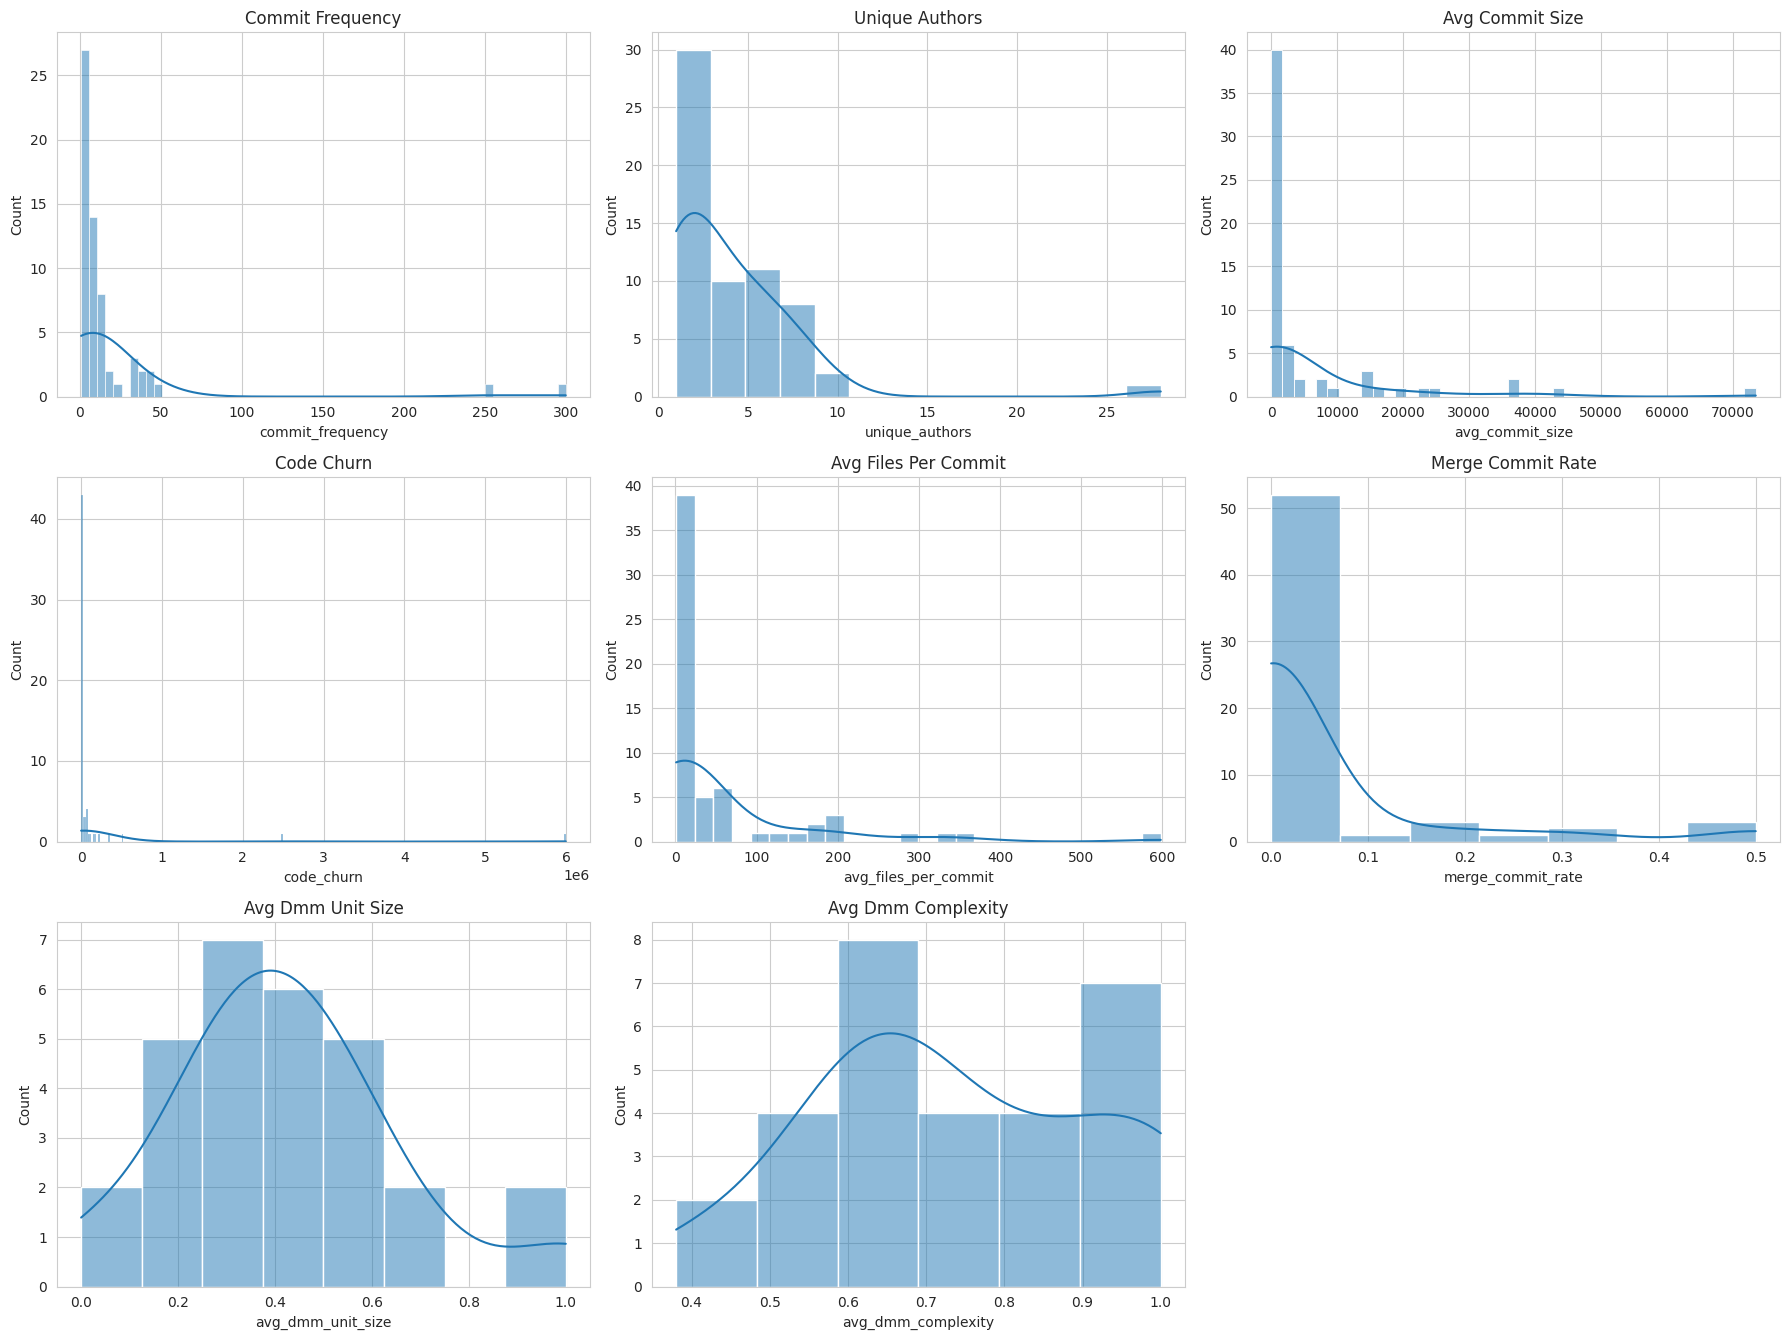

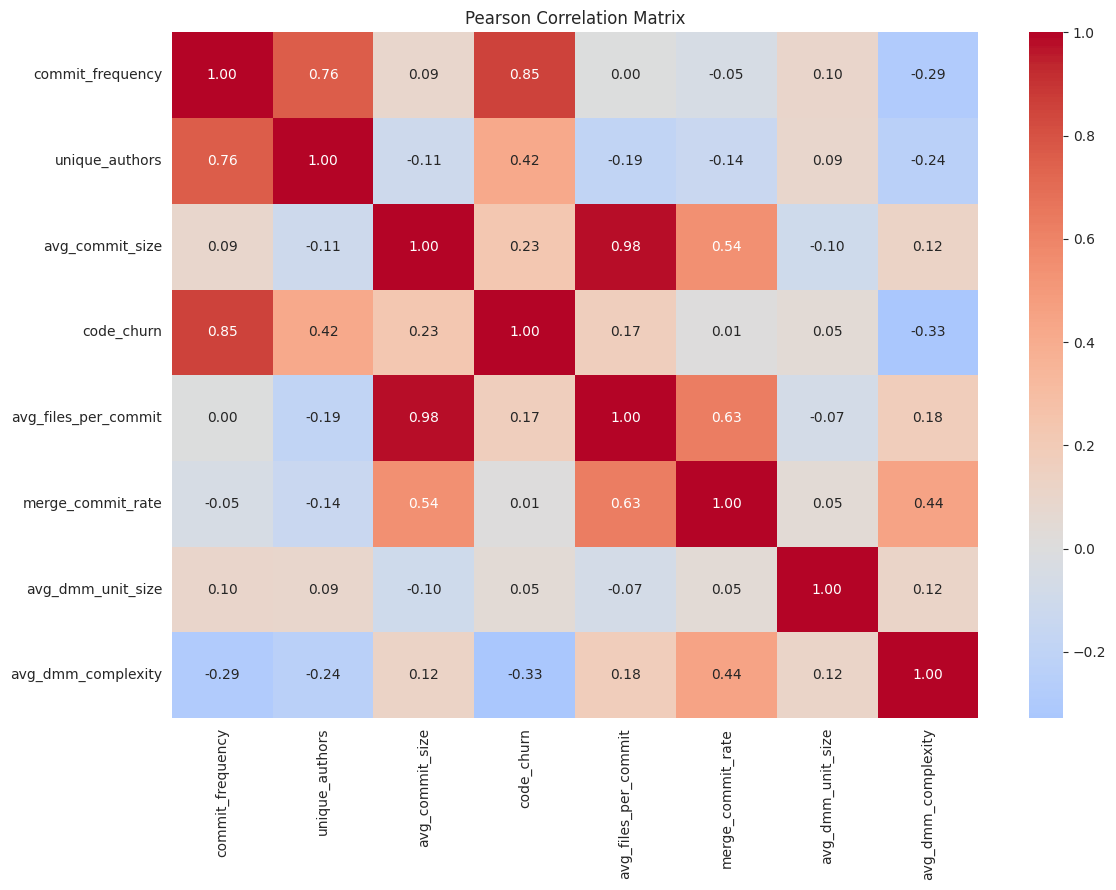

,Feature,VIF
4,avg_files_per_commit,42.601
2,avg_commit_size,36.809
0,commit_frequency,13.916
3,code_churn,7.663
1,unique_authors,4.513
5,merge_commit_rate,2.522
7,avg_dmm_complexity,1.506
6,avg_dmm_unit_size,1.091


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,commit_frequency,-12.000,28.000,10,16.129
1,unique_authors,-5.000,11.000,1,1.613
2,avg_commit_size,-5104.709,8566.266,12,19.355
3,code_churn,-61695.375,103201.625,8,12.903
4,avg_files_per_commit,-67.750,118.250,11,17.742
5,merge_commit_rate,0.000,0.000,14,22.581
6,avg_dmm_unit_size,0.005,0.815,4,6.452
7,avg_dmm_complexity,0.246,1.265,0,0.000


In [6]:
# ============================================================================
# MODULE 2B — FEATURE DISTRIBUTIONS, CORRELATION, VIF, OUTLIERS
# ============================================================================

eda_candidate_features = [
    "commit_frequency",
    "unique_authors",
    "avg_commit_size",
    "code_churn",
    "avg_files_per_commit",
    "merge_commit_rate",
    "avg_dmm_unit_size",
    "avg_dmm_complexity",
]

eda_features = [
    c for c in eda_candidate_features
    if (
        c in df.columns
        and df[c].notna().sum() >= 3
        and df[c].nunique(dropna=True) > 1
    )
]

# Descriptive table
eda_descriptive = df[eda_features].describe().T
eda_descriptive["median"] = df[eda_features].median()
eda_descriptive["skewness"] = df[eda_features].skew()
eda_descriptive["kurtosis"] = df[eda_features].kurtosis()
display(eda_descriptive.round(3))
eda_descriptive.to_csv(
    EDA_TABLE_PATH / "descriptive_statistics.csv"
)

# Feature distributions
n_cols = 3
n_rows = math.ceil(len(eda_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4.5 * n_rows),
)
axes = np.asarray(axes).reshape(-1)

for i, feature in enumerate(eda_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[i],
    )
    axes[i].set_title(
        feature.replace("_", " ").title()
    )

for j in range(len(eda_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(
    EDA_FIGURE_PATH / "feature_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Correlation
corr_data = df[eda_features].copy()
corr_data = corr_data.apply(
    lambda col: col.fillna(col.median())
)

pearson_corr = corr_data.corr(method="pearson")
pearson_corr.to_csv(
    EDA_TABLE_PATH / "pearson_correlation_matrix.csv"
)

plt.figure(figsize=(12, 9))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(
    EDA_FIGURE_PATH / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# VIF
scaled_for_vif = StandardScaler().fit_transform(corr_data)
vif_table = pd.DataFrame(
    {
        "Feature": eda_features,
        "VIF": [
            variance_inflation_factor(
                scaled_for_vif,
                i,
            )
            for i in range(len(eda_features))
        ],
    }
).sort_values("VIF", ascending=False)

display(vif_table.round(3))
vif_table.to_csv(
    EDA_TABLE_PATH / "vif_analysis.csv",
    index=False,
)

# IQR outlier summary
outlier_rows = []

for feature in eda_features:
    values = df[feature].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (
        (df[feature] < lower)
        | (df[feature] > upper)
    )

    outlier_rows.append(
        {
            "Feature": feature,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Outlier Count": int(mask.sum()),
            "Outlier Percentage": mask.mean() * 100,
        }
    )

outlier_table = pd.DataFrame(outlier_rows)
display(outlier_table.round(3))

outlier_table.to_csv(
    EDA_TABLE_PATH / "outlier_analysis.csv",
    index=False,
)

In [7]:
# ============================================================================
# MODULE 2C — SAMPLE SIZE FEASIBILITY TABLE
# ============================================================================

# RQ1: Approximate sample size for detecting Pearson correlation r = 0.30
# using Fisher's z transformation, alpha = .05, power = .80.
alpha = 0.05
power = 0.80
expected_r = 0.30

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(power)
fisher_z = np.arctanh(expected_r)

rq1_required_n = math.ceil(
    ((z_alpha + z_beta) / fisher_z) ** 2 + 3
)

available_n = len(df)

sample_size_table = pd.DataFrame(
    [
        {
            "Research Question": "RQ1",
            "Analysis": "Pearson/Spearman association",
            "Basis": "Fisher z; r=.30, alpha=.05, power=.80",
            "Minimum / Feasibility Target": rq1_required_n,
            "Available Observations": available_n,
            "Status": (
                "Meets target"
                if available_n >= rq1_required_n
                else "Below target — limitation to report"
            ),
        },
        {
            "Research Question": "RQ2",
            "Analysis": "Multiclass supervised ML",
            "Basis": "Stratified CV requires observations in every class/fold",
            "Minimum / Feasibility Target": ">=2 per class for 2-fold; >=10 per class for 10-fold",
            "Available Observations": available_n,
            "Status": "Adaptive stratified CV used",
        },
        {
            "Research Question": "RQ3",
            "Analysis": "Gap identification / feature importance",
            "Basis": "Depends on fitted predictive model and stable feature estimates",
            "Minimum / Feasibility Target": "No universal closed-form minimum",
            "Available Observations": available_n,
            "Status": "Exploratory; validate with larger dataset",
        },
        {
            "Research Question": "RQ4",
            "Analysis": "SHAP explainability",
            "Basis": "Depends on fitted model and representative observations",
            "Minimum / Feasibility Target": "No universal closed-form minimum",
            "Available Observations": available_n,
            "Status": "Exploratory; validate with larger dataset",
        },
    ]
)

display(sample_size_table)

sample_size_table.to_csv(
    EDA_TABLE_PATH / "sample_size_by_research_question.csv",
    index=False,
)

,Research Question,Analysis,Basis,Minimum / Feasibility Target,Available Observations,Status
0,RQ1,Pearson/Spearman association,"Fisher z; r=.30, alpha=.05, power=.80",85,62,Below target — limitation to report
1,RQ2,Multiclass supervised ML,Stratified CV requires observations in every c...,>=2 per class for 2-fold; >=10 per class for 1...,62,Adaptive stratified CV used
2,RQ3,Gap identification / feature importance,Depends on fitted predictive model and stable ...,No universal closed-form minimum,62,Exploratory; validate with larger dataset
3,RQ4,SHAP explainability,Depends on fitted model and representative obs...,No universal closed-form minimum,62,Exploratory; validate with larger dataset


# Module 3 — Feature Engineering

Repository metrics are transformed into higher-level process indicators. This operationalisation is a **research proxy mapping**, not an assessor-assigned Automotive SPICE capability rating.

In [8]:
# ============================================================================
# MODULE 3 — ENGINEER REPOSITORY-DERIVED PROCESS INDICATORS
# ============================================================================

def percentile_score(series, higher_is_better=True):
    score = (
        pd.to_numeric(series, errors="coerce")
        .rank(method="average", pct=True)
        * 100
    )
    return score if higher_is_better else 100 - score


def bounded_percentile_score(series):
    values = pd.to_numeric(series, errors="coerce")
    median = values.median()
    q10 = values.quantile(0.10)
    q90 = values.quantile(0.90)

    scale = max(
        abs(q10 - median),
        abs(q90 - median),
        1e-9,
    )

    return (
        (1 - abs(values - median) / scale) * 100
    ).clip(0, 100)


def engineer_repository_indicators(repository_df):
    result = repository_df.copy()

    result["indicator_planning_effectiveness"] = percentile_score(
        result["commit_frequency"],
        higher_is_better=True,
    )

    result["indicator_team_collaboration"] = percentile_score(
        result["unique_authors"],
        higher_is_better=True,
    )

    result["indicator_coding_discipline"] = percentile_score(
        result["avg_commit_size"],
        higher_is_better=False,
    )

    result["indicator_implementation_stability"] = (
        bounded_percentile_score(result["code_churn"])
    )

    result["indicator_change_manageability"] = percentile_score(
        result["avg_files_per_commit"],
        higher_is_better=False,
    )

    result["indicator_configuration_management"] = (
        bounded_percentile_score(
            result["merge_commit_rate"]
        )
    )

    if (
        "avg_dmm_complexity" in result.columns
        and result["avg_dmm_complexity"].notna().sum() >= 3
    ):
        result["indicator_design_quality"] = percentile_score(
            result["avg_dmm_complexity"],
            higher_is_better=False,
        )
    else:
        result["indicator_design_quality"] = np.nan

    result["author_diversity_ratio"] = (
        result["unique_authors"]
        / result["commit_frequency"].replace(0, np.nan)
    )

    result["indicator_resource_distribution"] = percentile_score(
        result["author_diversity_ratio"],
        higher_is_better=True,
    )

    return result


engineered_df = engineer_repository_indicators(df)

indicator_columns = [
    c for c in engineered_df.columns
    if c.startswith("indicator_")
]

display(
    engineered_df[
        [
            "project_id",
            "repository_name",
            *indicator_columns,
        ]
    ].head()
)

,project_id,repository_name,indicator_planning_effectiveness,indicator_team_collaboration,indicator_coding_discipline,indicator_implementation_stability,indicator_change_manageability,indicator_configuration_management,indicator_design_quality,indicator_resource_distribution
0,apollo-2017-07,apollo,100.000000,100.000000,19.354839,0.000000,46.774194,72.881356,44.827586,6.451613
1,autoware-2021-11,autoware,7.258065,15.322581,66.129032,99.342378,95.161290,100.000000,NaN,90.322581
2,autoware-2021-12,autoware,7.258065,15.322581,40.322581,99.784753,41.935484,100.000000,NaN,90.322581
3,autoware-2022-01,autoware,77.419355,53.225806,56.451613,99.927319,49.193548,100.000000,NaN,20.967742
4,autoware-2022-02,autoware,83.870968,86.290323,61.290323,99.993710,70.967742,100.000000,NaN,32.258065


# Module 4 — Repository-derived ASPICE Readiness Score

The process indicators are aggregated into process-area proxy scores and a composite repository-derived readiness score. The target classes are:

- **Low:** score < 40  
- **Moderate:** 40 ≤ score < 70  
- **High:** score ≥ 70

Readiness dataset shape: (62, 32)


,project_id,repository_name,repository_aspice_readiness_score,aspice_readiness_level
0,apollo-2017-07,apollo,48.840064,Moderate
1,autoware-2021-11,autoware,72.428959,High
2,autoware-2021-12,autoware,57.356144,Moderate
3,autoware-2022-01,autoware,70.751593,High
4,autoware-2022-02,autoware,80.643903,High
5,autoware-2022-03,autoware,78.339087,High
6,autoware-2022-04,autoware,78.648038,High
7,autoware-2022-05,autoware,79.549603,High
8,autoware-2022-06,autoware,86.549830,High
9,autoware-2022-07,autoware,76.320474,High


,Count
aspice_readiness_level,
Low,10
Moderate,25
High,27


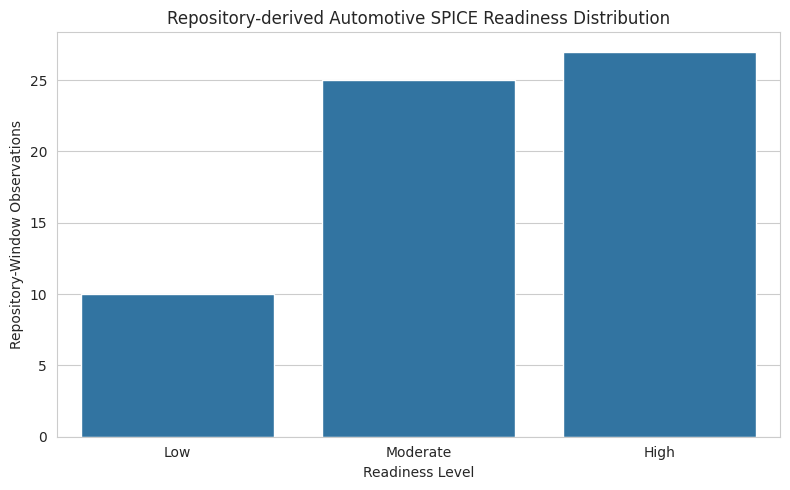

In [9]:
# ============================================================================
# MODULE 4 — PROCESS-AREA PROXIES AND READINESS TARGET
# ============================================================================

def build_repository_readiness_dataset(engineered_df):
    result = engineered_df.copy()

    result["proxy_SWE_1_score"] = result[
        [
            "indicator_planning_effectiveness",
            "indicator_change_manageability",
        ]
    ].mean(axis=1)

    result["proxy_SWE_2_3_score"] = result[
        [
            "indicator_implementation_stability",
            "indicator_coding_discipline",
            "indicator_design_quality",
        ]
    ].mean(axis=1, skipna=True)

    result["proxy_SWE_4_score"] = result[
        [
            "indicator_coding_discipline",
            "indicator_change_manageability",
        ]
    ].mean(axis=1)

    result["proxy_SWE_5_score"] = result[
        [
            "indicator_configuration_management",
            "indicator_implementation_stability",
        ]
    ].mean(axis=1)

    result["proxy_SUP_1_8_score"] = result[
        [
            "indicator_configuration_management",
            "indicator_change_manageability",
            "indicator_team_collaboration",
        ]
    ].mean(axis=1)

    result["proxy_MAN_3_score"] = result[
        [
            "indicator_planning_effectiveness",
            "indicator_team_collaboration",
            "indicator_resource_distribution",
        ]
    ].mean(axis=1)

    weights = {
        "proxy_SWE_1_score": 0.15,
        "proxy_SWE_2_3_score": 0.20,
        "proxy_SWE_4_score": 0.15,
        "proxy_SWE_5_score": 0.20,
        "proxy_SUP_1_8_score": 0.15,
        "proxy_MAN_3_score": 0.15,
    }

    weighted_sum = pd.Series(
        0.0,
        index=result.index,
    )
    available_weight = pd.Series(
        0.0,
        index=result.index,
    )

    for column, weight in weights.items():
        valid = result[column].notna()
        weighted_sum.loc[valid] += (
            result.loc[valid, column] * weight
        )
        available_weight.loc[valid] += weight

    result[SCORE_COLUMN] = (
        weighted_sum
        / available_weight.replace(0, np.nan)
    ).clip(0, 100)

    result[TARGET_COLUMN] = pd.cut(
        result[SCORE_COLUMN],
        bins=[-np.inf, 40, 70, np.inf],
        labels=CLASS_ORDER,
        right=False,
    )

    return result


readiness_df = build_repository_readiness_dataset(
    engineered_df
)

readiness_df.to_csv(
    PROCESSED_DATA_PATH
    / "repository_derived_aspice_dataset.csv",
    index=False,
)

print("Readiness dataset shape:", readiness_df.shape)
display(
    readiness_df[
        [
            "project_id",
            "repository_name",
            SCORE_COLUMN,
            TARGET_COLUMN,
        ]
    ].head(10)
)

class_distribution = (
    readiness_df[TARGET_COLUMN]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

display(
    class_distribution
    .rename("Count")
    .to_frame()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=class_distribution.index,
    y=class_distribution.values,
)
plt.title("Repository-derived Automotive SPICE Readiness Distribution")
plt.xlabel("Readiness Level")
plt.ylabel("Repository-Window Observations")
plt.tight_layout()
plt.savefig(
    EDA_FIGURE_PATH / "readiness_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Module 5 — Train Five Machine Learning Models

The predictor set intentionally excludes the composite readiness score and process-area proxy scores to avoid directly feeding the target construction back into the model.

Five models are compared:

1. Logistic Regression  
2. Random Forest  
3. XGBoost  
4. LightGBM  
5. Support Vector Machine

In [10]:
# ============================================================================
# MODULE 5 — MODELING DATASET AND ALGORITHMS
# ============================================================================

model_candidate_features = [
    "commit_frequency",
    "unique_authors",
    "avg_commit_size",
    "code_churn",
    "avg_files_per_commit",
    "merge_commit_rate",
    "avg_dmm_unit_size",
    "avg_dmm_complexity",
    "author_diversity_ratio",
]

model_features = [
    feature
    for feature in model_candidate_features
    if (
        feature in readiness_df.columns
        and readiness_df[feature].notna().sum() >= 3
        and readiness_df[feature].nunique(dropna=True) > 1
    )
]

model_df = readiness_df[
    model_features + [TARGET_COLUMN]
].dropna(
    subset=[TARGET_COLUMN]
).copy()

model_df[TARGET_COLUMN] = (
    model_df[TARGET_COLUMN]
    .astype(str)
)

model_df = model_df[
    model_df[TARGET_COLUMN].isin(CLASS_ORDER)
].copy()

X = model_df[model_features].copy()
y_labels = model_df[TARGET_COLUMN].copy()
y = y_labels.map(CLASS_TO_INT).astype(int)

class_counts = (
    y_labels
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

present_class_counts = class_counts[
    class_counts > 0
]

if len(present_class_counts) < 2:
    raise ValueError(
        "At least two readiness classes are required."
    )

minimum_class_count = int(
    present_class_counts.min()
)

outer_splits = min(
    10,
    minimum_class_count,
)

if outer_splits < 2:
    raise ValueError(
        "At least two observations are required in every present class."
    )

outer_cv = StratifiedKFold(
    n_splits=outer_splits,
    shuffle=True,
    random_state=42,
)

print("Modeling observations:", len(model_df))
print("Model features:", model_features)
print("Class distribution:")
display(class_counts.rename("Count").to_frame())
print("Outer stratified CV folds:", outer_splits)

if outer_splits < 10:
    print(
        "NOTE: The smallest readiness class does not support 10-fold CV. "
        f"{outer_splits}-fold stratified CV is used instead."
    )

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

models_and_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42,
        ),
        "grid": {
            "classifier__C": [0.01, 0.1, 1, 10],
            "classifier__solver": ["lbfgs", "liblinear"],
        },
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "grid": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 4, 8],
            "classifier__min_samples_split": [2, 5],
            "classifier__min_samples_leaf": [1, 2],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
        ),
        "grid": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [2, 3, 5],
            "classifier__learning_rate": [0.03, 0.1],
            "classifier__subsample": [0.8, 1.0],
        },
    },
    "LightGBM": {
        "model": LGBMClassifier(
            objective="multiclass",
            class_weight="balanced",
            random_state=42,
            verbosity=-1,
            n_jobs=-1,
        ),
        "grid": {
            "classifier__n_estimators": [50, 100],
            "classifier__learning_rate": [0.03, 0.1],
            "classifier__num_leaves": [7, 15, 31],
            "classifier__max_depth": [-1, 3, 5],
        },
    },
    "Support Vector Machine": {
        "model": SVC(
            probability=True,
            class_weight="balanced",
            random_state=42,
        ),
        "grid": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"],
            "classifier__gamma": ["scale", "auto"],
        },
    },
}

print("Models configured:")
for name in models_and_grids:
    print(" -", name)

Modeling observations: 62
Model features: ['commit_frequency', 'unique_authors', 'avg_commit_size', 'code_churn', 'avg_files_per_commit', 'merge_commit_rate', 'avg_dmm_unit_size', 'avg_dmm_complexity', 'author_diversity_ratio']
Class distribution:


,Count
aspice_readiness_level,
Low,10
Moderate,25
High,27


Outer stratified CV folds: 10
Models configured:
 - Logistic Regression
 - Random Forest
 - XGBoost
 - LightGBM
 - Support Vector Machine


# Module 6 — Hyperparameter Tuning with Nested Stratified Cross-Validation

This module uses **nested cross-validation** rather than selecting hyperparameters on the complete dataset and then evaluating on the same data.

- **Outer CV:** estimates generalisation performance.
- **Inner GridSearchCV:** tunes hyperparameters using only the outer-training fold.

This reduces optimistic bias and is more defensible for the final dissertation.

In [11]:
# ============================================================================
# MODULE 6 — NESTED STRATIFIED CROSS-VALIDATION
# ============================================================================

all_fold_results = []
nested_predictions = {}
nested_probabilities = {}
nested_best_params = {}

present_classes = sorted(y.unique())
n_classes = len(present_classes)

for model_name, specification in models_and_grids.items():
    print("\n" + "=" * 80)
    print("NESTED CV:", model_name)
    print("=" * 80)

    model_oof_predictions = np.full(
        len(X),
        fill_value=-1,
        dtype=int,
    )
    model_oof_probabilities = np.full(
        (len(X), n_classes),
        fill_value=np.nan,
        dtype=float,
    )

    fold_parameter_rows = []

    for fold_number, (train_idx, test_idx) in enumerate(
        outer_cv.split(X, y),
        start=1,
    ):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        train_class_counts = y_train.value_counts()
        min_train_class_count = int(
            train_class_counts.min()
        )

        inner_splits = min(
            5,
            min_train_class_count,
        )

        if inner_splits < 2:
            raise ValueError(
                f"Fold {fold_number} of {model_name} does not have "
                "enough observations per class for inner CV."
            )

        inner_cv = StratifiedKFold(
            n_splits=inner_splits,
            shuffle=True,
            random_state=1000 + fold_number,
        )

        pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(preprocessor),
                ),
                (
                    "classifier",
                    clone(specification["model"]),
                ),
            ]
        )

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=specification["grid"],
            scoring="f1_macro",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            error_score="raise",
        )

        grid_search.fit(
            X_train,
            y_train,
        )

        fold_best_model = grid_search.best_estimator_

        y_pred = fold_best_model.predict(X_test)
        y_prob = fold_best_model.predict_proba(X_test)

        model_oof_predictions[test_idx] = y_pred

        # Align probability columns to the encoded present classes.
        fitted_classes = list(
            fold_best_model.named_steps[
                "classifier"
            ].classes_
        )

        for probability_column, class_value in enumerate(
            fitted_classes
        ):
            destination_column = present_classes.index(
                int(class_value)
            )
            model_oof_probabilities[
                test_idx,
                destination_column,
            ] = y_prob[:, probability_column]

        accuracy = accuracy_score(
            y_test,
            y_pred,
        )
        precision = precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        )
        recall = recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        )
        f1 = f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        )

        try:
            roc_auc = roc_auc_score(
                y_test,
                y_prob,
                labels=fitted_classes,
                multi_class="ovr",
                average="weighted",
            )
        except Exception:
            roc_auc = np.nan

        all_fold_results.append(
            {
                "Model": model_name,
                "Fold": fold_number,
                "Outer Test Size": len(test_idx),
                "Inner CV Folds": inner_splits,
                "Accuracy": accuracy,
                "Precision Macro": precision,
                "Recall Macro": recall,
                "F1 Macro": f1,
                "ROC-AUC Weighted OVR": roc_auc,
            }
        )

        fold_parameter_rows.append(
            {
                "Fold": fold_number,
                "Best Inner-CV F1": grid_search.best_score_,
                "Best Parameters": json.dumps(
                    grid_search.best_params_,
                    sort_keys=True,
                ),
            }
        )

        print(
            f"Fold {fold_number}: "
            f"F1={f1:.3f}, "
            f"Accuracy={accuracy:.3f}, "
            f"ROC-AUC={roc_auc:.3f}"
            if not np.isnan(roc_auc)
            else
            f"Fold {fold_number}: "
            f"F1={f1:.3f}, Accuracy={accuracy:.3f}"
        )

    nested_predictions[model_name] = model_oof_predictions
    nested_probabilities[model_name] = model_oof_probabilities

    nested_best_params[model_name] = pd.DataFrame(
        fold_parameter_rows
    )

fold_results_df = pd.DataFrame(all_fold_results)

display(fold_results_df.head())

fold_results_df.to_csv(
    MODEL_TABLE_PATH / "nested_cv_fold_results.csv",
    index=False,
)


NESTED CV: Logistic Regression
Fold 1: F1=0.886, Accuracy=0.857, ROC-AUC=1.000
Fold 2: F1=0.578, Accuracy=0.571, ROC-AUC=0.857
Fold 3: F1=0.722, Accuracy=0.667, ROC-AUC=0.750
Fold 4: F1=0.656, Accuracy=0.667, ROC-AUC=0.847
Fold 5: F1=0.841, Accuracy=0.833, ROC-AUC=1.000
Fold 6: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 7: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 8: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 9: F1=0.452, Accuracy=0.667, ROC-AUC=0.861
Fold 10: F1=0.867, Accuracy=0.833, ROC-AUC=0.903

NESTED CV: Random Forest
Fold 1: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 2: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 3: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 4: F1=0.822, Accuracy=0.833, ROC-AUC=1.000
Fold 5: F1=0.524, Accuracy=0.500, ROC-AUC=0.597
Fold 6: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 7: F1=1.000, Accuracy=1.000, ROC-AUC=1.000
Fold 8: F1=0.778, Accuracy=0.833, ROC-AUC=0.958
Fold 9: F1=0.600, Accuracy=0.833, ROC-AUC=1.000
Fold 10: F1=0.600, Accuracy=0

,Model,Fold,Outer Test Size,Inner CV Folds,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC-AUC Weighted OVR
0,Logistic Regression,1,7,5,0.857143,0.916667,0.888889,0.885714,1.000000
1,Logistic Regression,2,7,5,0.571429,0.555556,0.666667,0.577778,0.857143
2,Logistic Regression,3,6,5,0.666667,0.833333,0.777778,0.722222,0.750000
3,Logistic Regression,4,6,5,0.666667,0.722222,0.777778,0.655556,0.847222
4,Logistic Regression,5,6,5,0.833333,0.916667,0.833333,0.841270,1.000000


# Module 7 — Evaluation Metrics

Performance is summarised using Accuracy, macro Precision, macro Recall, macro F1, and weighted one-vs-rest ROC-AUC.

In [12]:
# ============================================================================
# MODULE 7 — AGGREGATE MODEL EVALUATION METRICS
# ============================================================================

metric_columns = [
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "ROC-AUC Weighted OVR",
]

summary_rows = []

for model_name in models_and_grids:
    model_folds = fold_results_df[
        fold_results_df["Model"] == model_name
    ]

    row = {"Model": model_name}

    for metric in metric_columns:
        row[f"{metric} Mean"] = model_folds[metric].mean()
        row[f"{metric} Std"] = model_folds[metric].std()

    summary_rows.append(row)

model_comparison = (
    pd.DataFrame(summary_rows)
    .sort_values(
        [
            "F1 Macro Mean",
            "ROC-AUC Weighted OVR Mean",
            "Accuracy Mean",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(model_comparison.round(4))

model_comparison.to_csv(
    MODEL_TABLE_PATH / "model_comparison.csv",
    index=False,
)

,Model,Accuracy Mean,Accuracy Std,Precision Macro Mean,Precision Macro Std,Recall Macro Mean,Recall Macro Std,F1 Macro Mean,F1 Macro Std,ROC-AUC Weighted OVR Mean,ROC-AUC Weighted OVR Std
0,LightGBM,0.9167,0.1620,0.9167,0.1620,0.9278,0.1436,0.9124,0.1602,0.9244,0.1714
1,Random Forest,0.8833,0.1581,0.8278,0.2119,0.8611,0.1722,0.8324,0.1963,0.9556,0.1266
2,XGBoost,0.8690,0.1528,0.7972,0.2012,0.8333,0.1656,0.8019,0.1867,0.9183,0.1715
3,Logistic Regression,0.8095,0.1599,0.8250,0.2008,0.8333,0.1614,0.8002,0.1917,0.9218,0.0906
4,Support Vector Machine,0.6976,0.2027,0.7061,0.2542,0.7222,0.2144,0.6780,0.2411,0.8921,0.0935


# Module 8 — Model Comparison and Best-Model Selection

The best model is selected primarily by **mean macro F1**, with ROC-AUC and Accuracy used as secondary comparison criteria.

Selected best model: LightGBM


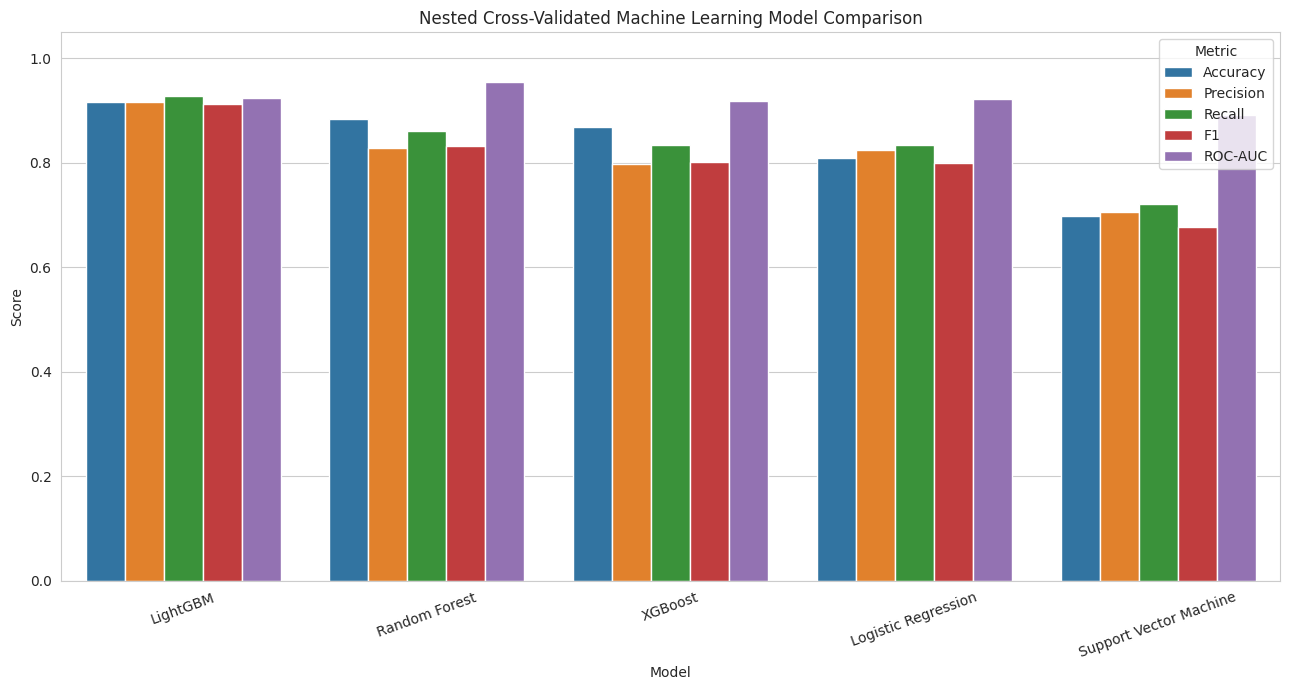

In [13]:
# ============================================================================
# MODULE 8A — MODEL COMPARISON FIGURE AND BEST MODEL
# ============================================================================

best_model_name = model_comparison.loc[
    0,
    "Model",
]

print("Selected best model:", best_model_name)

plot_metrics = pd.DataFrame(
    {
        "Model": model_comparison["Model"],
        "Accuracy": model_comparison["Accuracy Mean"],
        "Precision": model_comparison["Precision Macro Mean"],
        "Recall": model_comparison["Recall Macro Mean"],
        "F1": model_comparison["F1 Macro Mean"],
        "ROC-AUC": model_comparison["ROC-AUC Weighted OVR Mean"],
    }
)

plot_long = plot_metrics.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=plot_long,
    x="Model",
    y="Score",
    hue="Metric",
)
plt.ylim(0, 1.05)
plt.title("Nested Cross-Validated Machine Learning Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    MODEL_FIGURE_PATH / "model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

,precision,recall,f1-score,support
Low,0.8333,1.0000,0.9091,10.0000
Moderate,0.9167,0.8800,0.8980,25.0000
High,0.9615,0.9259,0.9434,27.0000
accuracy,0.9194,0.9194,0.9194,0.9194
macro avg,0.9038,0.9353,0.9168,62.0000
weighted avg,0.9228,0.9194,0.9195,62.0000


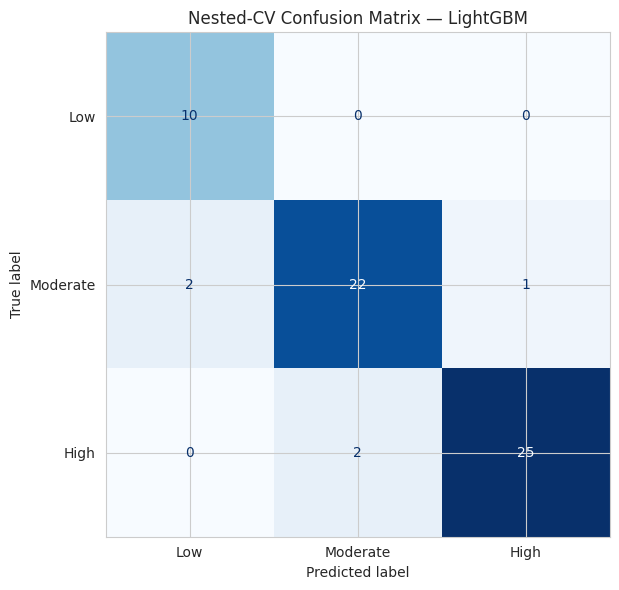

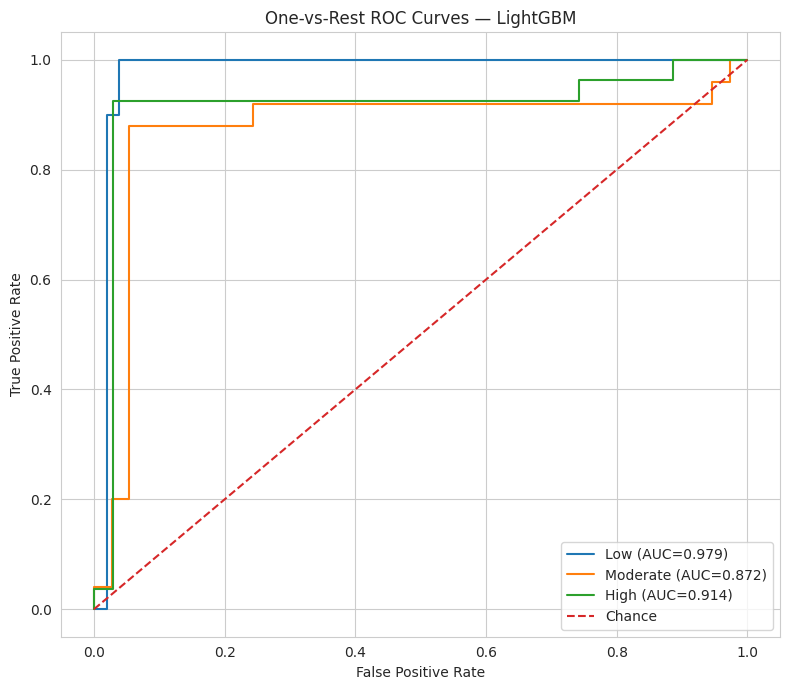

In [14]:
# ============================================================================
# MODULE 8B — OUT-OF-FOLD CLASSIFICATION REPORT, CONFUSION MATRIX, ROC
# ============================================================================

best_predictions = nested_predictions[
    best_model_name
]

best_probabilities = nested_probabilities[
    best_model_name
]

report = classification_report(
    y,
    best_predictions,
    labels=present_classes,
    target_names=[
        INT_TO_CLASS[i]
        for i in present_classes
    ],
    output_dict=True,
    zero_division=0,
)

classification_report_df = pd.DataFrame(
    report
).T

display(
    classification_report_df.round(4)
)

classification_report_df.to_csv(
    MODEL_TABLE_PATH
    / "best_model_classification_report.csv"
)

cm = confusion_matrix(
    y,
    best_predictions,
    labels=present_classes,
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        INT_TO_CLASS[i]
        for i in present_classes
    ],
).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)

ax.set_title(
    f"Nested-CV Confusion Matrix — {best_model_name}"
)

plt.tight_layout()
plt.savefig(
    MODEL_FIGURE_PATH
    / "best_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# ROC curves from nested out-of-fold probabilities
y_binary = label_binarize(
    y,
    classes=present_classes,
)

fig, ax = plt.subplots(figsize=(8, 7))

for class_position, class_value in enumerate(
    present_classes
):
    fpr, tpr, _ = roc_curve(
        y_binary[:, class_position],
        best_probabilities[:, class_position],
    )

    class_auc = auc(
        fpr,
        tpr,
    )

    ax.plot(
        fpr,
        tpr,
        label=(
            f"{INT_TO_CLASS[class_value]} "
            f"(AUC={class_auc:.3f})"
        ),
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)

ax.set_title(
    f"One-vs-Rest ROC Curves — {best_model_name}"
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(
    MODEL_FIGURE_PATH
    / "best_model_roc_curves.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [15]:
# ============================================================================
# MODULE 8C — FINAL HYPERPARAMETER SEARCH ON ALL DATA FOR DEPLOYMENT MODEL
# ============================================================================

best_specification = models_and_grids[
    best_model_name
]

full_data_min_class_count = int(
    y.value_counts().min()
)

final_inner_splits = min(
    5,
    full_data_min_class_count,
)

final_inner_cv = StratifiedKFold(
    n_splits=final_inner_splits,
    shuffle=True,
    random_state=2026,
)

final_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "classifier",
            clone(
                best_specification["model"]
            ),
        ),
    ]
)

final_grid_search = GridSearchCV(
    estimator=final_pipeline,
    param_grid=best_specification["grid"],
    scoring="f1_macro",
    cv=final_inner_cv,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

final_grid_search.fit(
    X,
    y,
)

final_best_model = final_grid_search.best_estimator_
final_best_parameters = final_grid_search.best_params_

print("Deployment model:", best_model_name)
print("Final GridSearchCV best F1:", final_grid_search.best_score_)
print("Best parameters:")
print(final_best_parameters)

# Appendix E — actual hyperparameter results for every model
final_hyperparameter_rows = []
final_estimators = {}

for model_name, specification in models_and_grids.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", clone(specification["model"])),
        ]
    )

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=specification["grid"],
        scoring="f1_macro",
        cv=final_inner_cv,
        n_jobs=-1,
        refit=True,
        error_score="raise",
    )

    grid.fit(X, y)

    final_estimators[model_name] = grid.best_estimator_

    final_hyperparameter_rows.append(
        {
            "Model": model_name,
            "Best CV Macro F1": grid.best_score_,
            "Best Parameters": json.dumps(
                grid.best_params_,
                sort_keys=True,
            ),
        }
    )

appendix_e_table = pd.DataFrame(
    final_hyperparameter_rows
).sort_values(
    "Best CV Macro F1",
    ascending=False,
)

display(
    appendix_e_table
)

appendix_e_table.to_csv(
    MODEL_TABLE_PATH
    / "Appendix_E_Actual_Best_Hyperparameters.csv",
    index=False,
)

Deployment model: LightGBM
Final GridSearchCV best F1: 0.8530680430680431
Best parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': -1, 'classifier__n_estimators': 100, 'classifier__num_leaves': 7}


,Model,Best CV Macro F1,Best Parameters
1,Random Forest,0.865848,"{""classifier__max_depth"": null, ""classifier__m..."
0,Logistic Regression,0.855781,"{""classifier__C"": 10, ""classifier__solver"": ""l..."
3,LightGBM,0.853068,"{""classifier__learning_rate"": 0.1, ""classifier..."
2,XGBoost,0.837700,"{""classifier__learning_rate"": 0.03, ""classifie..."
4,Support Vector Machine,0.808316,"{""classifier__C"": 1, ""classifier__gamma"": ""sca..."


In [17]:
# ============================================================================
# SENSITIVITY ANALYSIS — IMPACT OF IQR OUTLIER RETENTION
# ============================================================================

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 1. Identify IQR outliers in the FINAL modelling predictors
# ---------------------------------------------------------------------------

outlier_mask = pd.Series(False, index=X.index)

outlier_detail = []

for feature in model_features:
    values = X[feature].dropna()

    # Skip features without enough usable variation
    if len(values) < 3 or values.nunique() <= 1:
        continue

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    feature_mask = (
        (X[feature] < lower_bound) |
        (X[feature] > upper_bound)
    ).fillna(False)

    outlier_mask = outlier_mask | feature_mask

    outlier_detail.append({
        "Feature": feature,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Observations": int(feature_mask.sum())
    })

outlier_detail_df = pd.DataFrame(outlier_detail)

print("Original observations:", len(X))
print("Observations flagged as IQR outliers:", int(outlier_mask.sum()))
print("Observations remaining after removal:", int((~outlier_mask).sum()))

display(outlier_detail_df.round(3))


# ---------------------------------------------------------------------------
# 2. Create IQR-filtered sensitivity dataset
# ---------------------------------------------------------------------------

X_filtered = X.loc[~outlier_mask].copy()
y_filtered = y.loc[~outlier_mask].copy()

print("\nClass distribution after IQR filtering:")
# Add explicit check for the number of unique classes after filtering
if y_filtered.nunique() < 2:
    raise ValueError(
        "Less than two unique classes remain after IQR filtering. "
        "Cannot perform multiclass classification."
    )

# Re-map classes to be contiguous starting from 0 if there are gaps
# This is crucial if original classes were [0, 1, 2] and now only [1, 2] remain
# `y_filtered_mapped` will have labels [0, 1] if original were [1, 2]
unique_classes_filtered = sorted(y_filtered.unique())
class_mapping = {cls: i for i, cls in enumerate(unique_classes_filtered)}
y_filtered_mapped = y_filtered.map(class_mapping)

display(
    y_filtered_mapped.value_counts() # Display mapped counts
    .sort_index()
    .rename("Count")
    .to_frame()
)

# Number of classes for LightGBM
n_classes_filtered = y_filtered_mapped.nunique()


# ---------------------------------------------------------------------------
# 3. Re-run LightGBM using nested stratified cross-validation
# ---------------------------------------------------------------------------

lightgbm_spec = models_and_grids["LightGBM"]

# Use the mapped y_filtered for calculations
minimum_filtered_class = int(
    y_filtered_mapped.value_counts().min()
)

filtered_outer_splits = min(
    10,
    minimum_filtered_class
)

if filtered_outer_splits < 2:
    raise ValueError(
        "Insufficient observations per class after IQR filtering for outer CV."
    )

filtered_outer_cv = StratifiedKFold(
    n_splits=filtered_outer_splits,
    shuffle=True,
    random_state=42,
)

sensitivity_fold_results = []

for fold_number, (train_idx, test_idx) in enumerate(
    filtered_outer_cv.split(X_filtered, y_filtered_mapped), # Use y_filtered_mapped here
    start=1
):

    X_train = X_filtered.iloc[train_idx]
    X_test = X_filtered.iloc[test_idx]

    y_train = y_filtered_mapped.iloc[train_idx] # Use y_filtered_mapped here
    y_test = y_filtered_mapped.iloc[test_idx]   # Use y_filtered_mapped here

    # Explicit check for unique classes in y_train
    if y_train.nunique() < 2:
        print(
            f"Skipping fold {fold_number} due to insufficient unique classes in training data "
            f"after IQR filtering: {y_train.nunique()} unique classes found."
        )
        continue # Skip this fold, as LightGBM will error

    min_train_class = int(
        y_train.value_counts().min()
    )

    inner_splits = min(
        5,
        min_train_class
    )

    if inner_splits < 2:
        # This condition is already there, but now with y_filtered_mapped
        raise ValueError(
            f"Fold {fold_number} of LightGBM does not have "
            "enough observations per class for inner CV after IQR filtering."
        )

    inner_cv = StratifiedKFold(
        n_splits=inner_splits,
        shuffle=True,
        random_state=1000 + fold_number
    )

    # Clone the model for each run to ensure clean state
    lgbm_model = clone(lightgbm_spec["model"])
    # Pass num_class explicitly to LightGBM if we re-encoded labels
    # However, LightGBM usually infers num_class from y if not provided.
    # The error implies y_train had only 1 class in some fold.
    # Setting num_class might bypass inference issues if num_class was implicitly derived previously.
    lgbm_model.set_params(num_class=n_classes_filtered)


    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "classifier",
                lgbm_model # Use the configured lgbm_model
            ),
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=lightgbm_spec["grid"],
        scoring="f1_macro",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        error_score="raise"
    )

    grid_search.fit(
        X_train,
        y_train
    )

    model = grid_search.best_estimator_

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    try:
        # Ensure labels are correct for ROC-AUC calculation
        roc_auc = roc_auc_score(
            y_test,
            y_prob,
            labels=np.arange(n_classes_filtered), # Use contiguous labels
            multi_class="ovr",
            average="weighted"
        )
    except Exception:
        roc_auc = np.nan

    sensitivity_fold_results.append({
        "Fold": fold_number,
        "Accuracy": accuracy,
        "Precision Macro": precision,
        "Recall Macro": recall,
        "F1 Macro": f1,
        "ROC-AUC": roc_auc
    })


# If no folds completed, raise an error or handle gracefully
if not sensitivity_fold_results:
    raise RuntimeError("No folds could be processed in sensitivity analysis after filtering.")

sensitivity_results_df = pd.DataFrame(
    sensitivity_fold_results
)


# ---------------------------------------------------------------------------
# 4. Compare ORIGINAL vs IQR-FILTERED LightGBM
# ---------------------------------------------------------------------------

original_lightgbm = model_comparison[
    model_comparison["Model"] == "LightGBM"
].iloc[0]

sensitivity_comparison = pd.DataFrame([
    {
        "Scenario": "Outliers Retained",
        "N": len(X),
        "Accuracy": original_lightgbm["Accuracy Mean"],
        "Macro Precision":
            original_lightgbm["Precision Macro Mean"],
        "Macro Recall":
            original_lightgbm["Recall Macro Mean"],
        "Macro F1":
            original_lightgbm["F1 Macro Mean"],
        "ROC-AUC":
            original_lightgbm["ROC-AUC Weighted OVR Mean"],
    },
    {
        "Scenario": "IQR Outliers Removed",
        "N": len(X_filtered),
        "Accuracy":
            sensitivity_results_df["Accuracy"].mean(),
        "Macro Precision":
            sensitivity_results_df["Precision Macro"].mean(),
        "Macro Recall":
            sensitivity_results_df["Recall Macro"].mean(),
        "Macro F1":
            sensitivity_results_df["F1 Macro"].mean(),
        "ROC-AUC":
            sensitivity_results_df["ROC-AUC"].mean(),
    }
])

print("\nOUTLIER SENSITIVITY ANALYSIS")
display(
    sensitivity_comparison.round(3)
)

sensitivity_comparison.to_csv(
    MODEL_TABLE_PATH /
    "outlier_sensitivity_analysis.csv",
    index=False
)


Original observations: 62
Observations flagged as IQR outliers: 24
Observations remaining after removal: 38


,Feature,Lower Bound,Upper Bound,Outlier Observations
0,commit_frequency,-12.000,28.000,10
1,unique_authors,-5.000,11.000,1
2,avg_commit_size,-5104.709,8566.266,12
3,code_churn,-61695.375,103201.625,8
4,avg_files_per_commit,-67.750,118.250,11
5,merge_commit_rate,0.000,0.000,14
6,avg_dmm_unit_size,0.005,0.815,4
7,avg_dmm_complexity,0.246,1.265,0
8,author_diversity_ratio,-0.517,1.533,0



Class distribution after IQR filtering:


,Count
aspice_readiness_level,
0,14
1,24



OUTLIER SENSITIVITY ANALYSIS


,Scenario,N,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC
0,Outliers Retained,62,0.917,0.917,0.928,0.912,0.924
1,IQR Outliers Removed,38,0.633,0.317,0.500,0.385,NaN


# Module 9 — SHAP Explainability

SHAP is applied to the final fitted best model. The notebook exports:

- Global SHAP summary plot
- Global SHAP feature-importance table
- Dependence plot for the most influential feature
- Waterfall plot for one representative observation
- Local contribution plot
- Force-plot HTML
- SHAP interaction table when the selected model supports tree interactions

In [18]:
# ============================================================================
# MODULE 9A — PREPARE FINAL MODEL FOR SHAP
# ============================================================================

# Transform model inputs once through the fitted preprocessing pipeline.
X_transformed = final_best_model.named_steps[
    "preprocessor"
].transform(X)

X_explain = pd.DataFrame(
    X_transformed,
    columns=model_features,
    index=X.index,
)

final_classifier = final_best_model.named_steps[
    "classifier"
]

tree_model_names = {
    "Random Forest",
    "XGBoost",
    "LightGBM",
}

if best_model_name in tree_model_names:
    shap_explainer = shap.Explainer(
        final_classifier
    )
    shap_explanation = shap_explainer(
        X_explain
    )

elif best_model_name == "Logistic Regression":
    shap_explainer = shap.LinearExplainer(
        final_classifier,
        X_explain,
    )
    shap_explanation = shap_explainer(
        X_explain
    )

else:
    background = shap.sample(
        X_explain,
        min(20, len(X_explain)),
        random_state=42,
    )

    shap_explainer = shap.Explainer(
        final_classifier.predict_proba,
        background,
    )

    shap_explanation = shap_explainer(
        X_explain
    )

print("SHAP model:", best_model_name)
print("SHAP values shape:", np.asarray(shap_explanation.values).shape)

SHAP model: LightGBM
SHAP values shape: (62, 9, 3)


,Rank,Feature,Mean |SHAP|,Contribution (%)
0,1,avg_commit_size,1.2448,38.4344
1,2,avg_files_per_commit,0.5210,16.0848
2,3,commit_frequency,0.4507,13.9157
3,4,code_churn,0.4314,13.3199
4,5,unique_authors,0.3703,11.4322
5,6,author_diversity_ratio,0.2207,6.8131
6,7,merge_commit_rate,0.0000,0.0000
7,8,avg_dmm_unit_size,0.0000,0.0000
8,9,avg_dmm_complexity,0.0000,0.0000


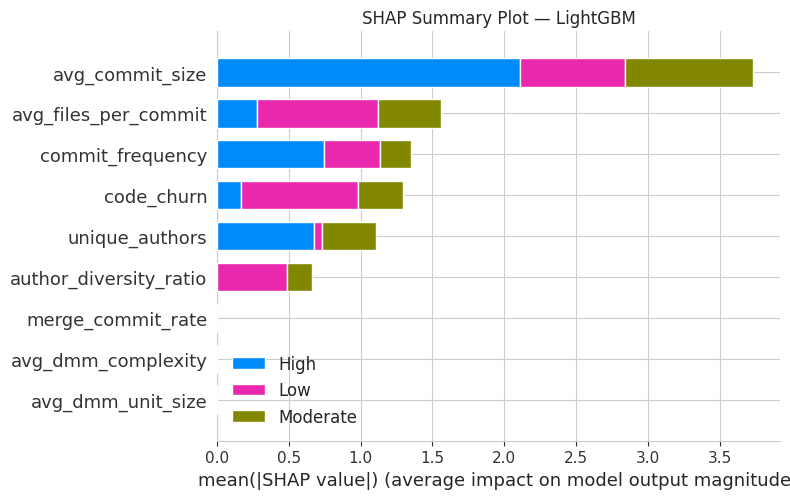

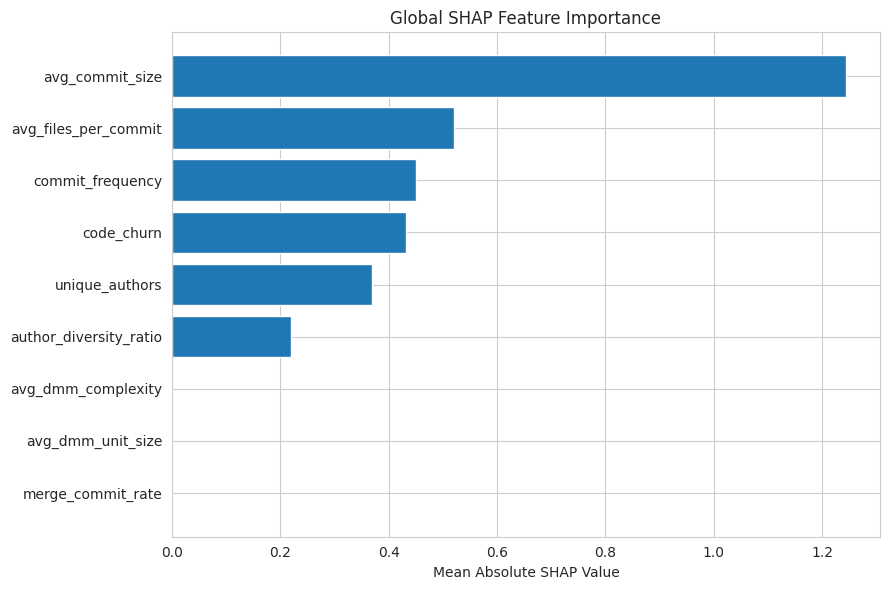

In [19]:
# ============================================================================
# MODULE 9B — GLOBAL SHAP SUMMARY AND FEATURE IMPORTANCE
# ============================================================================

shap_values_array = np.asarray(
    shap_explanation.values
)

if shap_values_array.ndim == 3:
    # samples x features x classes
    mean_abs_shap = np.abs(
        shap_values_array
    ).mean(axis=(0, 2))
else:
    # samples x features
    mean_abs_shap = np.abs(
        shap_values_array
    ).mean(axis=0)

shap_importance_table = (
    pd.DataFrame(
        {
            "Feature": model_features,
            "Mean |SHAP|": mean_abs_shap,
        }
    )
    .sort_values(
        "Mean |SHAP|",
        ascending=False,
    )
    .reset_index(drop=True)
)

shap_importance_table.insert(
    0,
    "Rank",
    range(
        1,
        len(shap_importance_table) + 1,
    ),
)

shap_importance_table[
    "Contribution (%)"
] = (
    shap_importance_table["Mean |SHAP|"]
    / shap_importance_table["Mean |SHAP|"].sum()
    * 100
)

display(
    shap_importance_table.round(4)
)

shap_importance_table.to_csv(
    SHAP_TABLE_PATH
    / "shap_global_feature_importance.csv",
    index=False,
)

plt.figure(figsize=(10, 7))

if shap_values_array.ndim == 3:
    summary_values = [
        shap_values_array[:, :, class_index]
        for class_index in range(
            shap_values_array.shape[2]
        )
    ]

    shap.summary_plot(
        summary_values,
        X_explain,
        feature_names=model_features,
        class_names=[
            INT_TO_CLASS.get(
                int(class_value),
                str(class_value),
            )
            for class_value in final_classifier.classes_
        ],
        show=False,
    )
else:
    shap.summary_plot(
        shap_values_array,
        X_explain,
        feature_names=model_features,
        show=False,
    )

plt.title(
    f"SHAP Summary Plot — {best_model_name}"
)
plt.tight_layout()
plt.savefig(
    SHAP_FIGURE_PATH
    / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Separate publication-friendly bar plot
top_shap = (
    shap_importance_table
    .head(10)
    .sort_values(
        "Mean |SHAP|",
        ascending=True,
    )
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_shap["Feature"],
    top_shap["Mean |SHAP|"],
)
plt.xlabel("Mean Absolute SHAP Value")
plt.title(
    "Global SHAP Feature Importance"
)
plt.tight_layout()
plt.savefig(
    SHAP_FIGURE_PATH
    / "shap_feature_importance_bar.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

<Figure size 800x600 with 0 Axes>

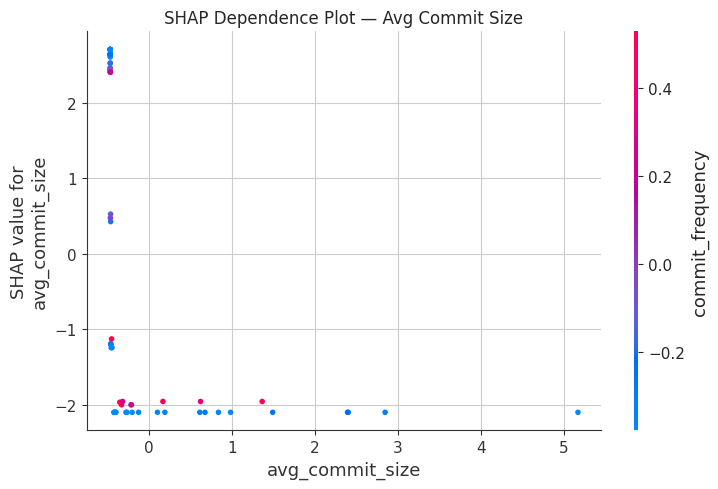

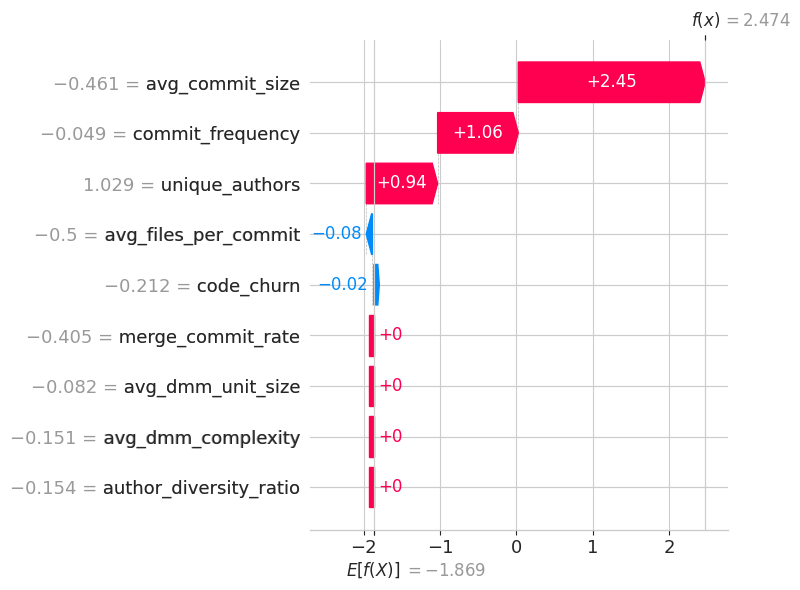

,Feature,SHAP Value,Absolute SHAP
2,avg_commit_size,2.4504,2.4504
0,commit_frequency,1.0574,1.0574
1,unique_authors,0.9359,0.9359
4,avg_files_per_commit,-0.0809,0.0809
3,code_churn,-0.0197,0.0197
5,merge_commit_rate,0.0000,0.0000
6,avg_dmm_unit_size,0.0000,0.0000
7,avg_dmm_complexity,0.0000,0.0000
8,author_diversity_ratio,0.0000,0.0000


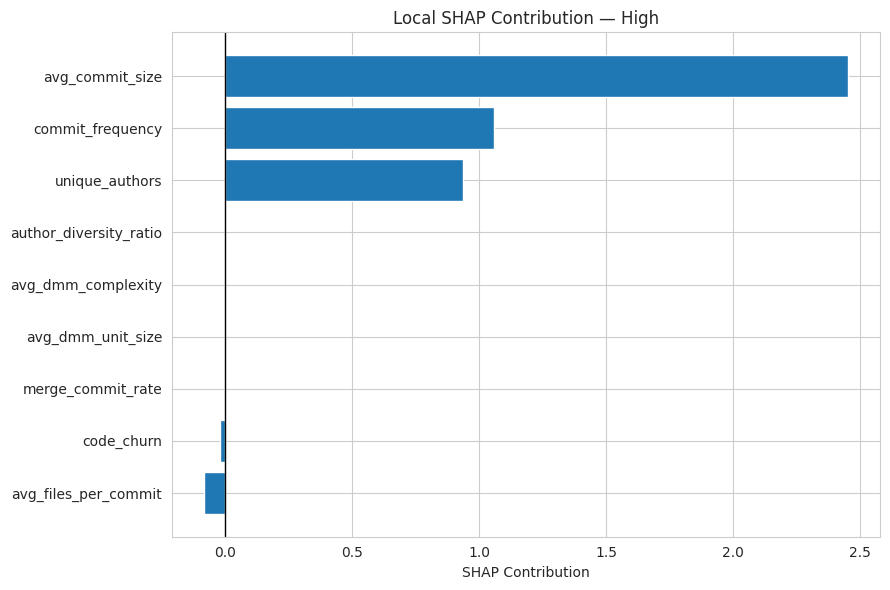

Interactive force plot saved: /content/figures/shap/shap_force_plot.html


In [20]:
# ============================================================================
# MODULE 9C — DEPENDENCE, WATERFALL, LOCAL CONTRIBUTION, FORCE PLOT
# ============================================================================

top_feature = shap_importance_table.loc[
    0,
    "Feature",
]

top_feature_index = model_features.index(
    top_feature
)

# Use High class when available; otherwise explain the first fitted class.
if 2 in list(final_classifier.classes_):
    target_class_value = 2
    target_class_position = list(
        final_classifier.classes_
    ).index(2)
else:
    target_class_position = 0
    target_class_value = int(
        final_classifier.classes_[0]
    )

if shap_values_array.ndim == 3:
    dependence_values = (
        shap_values_array[
            :,
            :,
            target_class_position,
        ]
    )
else:
    dependence_values = shap_values_array

plt.figure(figsize=(8, 6))
shap.dependence_plot(
    top_feature,
    dependence_values,
    X_explain,
    show=False,
)
plt.title(
    "SHAP Dependence Plot — "
    + top_feature.replace("_", " ").title()
)
plt.tight_layout()
plt.savefig(
    SHAP_FIGURE_PATH
    / "shap_dependence_plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Representative observation: highest-confidence prediction of target class
full_probabilities = final_classifier.predict_proba(
    X_explain
)
full_predictions = final_classifier.predict(
    X_explain
)

target_candidates = np.where(
    full_predictions == target_class_value
)[0]

if len(target_candidates) > 0:
    target_probability_column = list(
        final_classifier.classes_
    ).index(target_class_value)

    observation_index = target_candidates[
        np.argmax(
            full_probabilities[
                target_candidates,
                target_probability_column,
            ]
        )
    ]
else:
    observation_index = int(
        np.argmax(
            full_probabilities.max(axis=1)
        )
    )

predicted_class_value = int(
    full_predictions[observation_index]
)

predicted_class_position = list(
    final_classifier.classes_
).index(
    predicted_class_value
)

if shap_values_array.ndim == 3:
    if np.asarray(
        shap_explanation.base_values
    ).ndim == 2:
        base_value = shap_explanation.base_values[
            observation_index,
            predicted_class_position,
        ]
    else:
        base_value = shap_explanation.base_values[
            predicted_class_position
        ]

    single_explanation = shap.Explanation(
        values=shap_values_array[
            observation_index,
            :,
            predicted_class_position,
        ],
        base_values=base_value,
        data=X_explain.iloc[
            observation_index
        ].values,
        feature_names=model_features,
    )

else:
    base_values_array = np.asarray(
        shap_explanation.base_values
    )

    if base_values_array.ndim == 0:
        base_value = float(
            base_values_array
        )
    else:
        base_value = base_values_array[
            observation_index
        ]

    single_explanation = shap.Explanation(
        values=shap_values_array[
            observation_index,
            :
        ],
        base_values=base_value,
        data=X_explain.iloc[
            observation_index
        ].values,
        feature_names=model_features,
    )

# Waterfall
plt.figure(figsize=(10, 7))
shap.plots.waterfall(
    single_explanation,
    max_display=12,
    show=False,
)
plt.tight_layout()
plt.savefig(
    SHAP_FIGURE_PATH
    / "shap_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Local contribution bar chart: reliable PNG alternative to a force plot screenshot.
local_contribution_table = pd.DataFrame(
    {
        "Feature": model_features,
        "SHAP Value": single_explanation.values,
        "Absolute SHAP": np.abs(
            single_explanation.values
        ),
    }
).sort_values(
    "Absolute SHAP",
    ascending=False,
)

display(
    local_contribution_table.head(10).round(4)
)

local_contribution_table.to_csv(
    SHAP_TABLE_PATH
    / "shap_local_contribution_example.csv",
    index=False,
)

local_top = (
    local_contribution_table
    .head(10)
    .sort_values("SHAP Value")
)

plt.figure(figsize=(9, 6))
plt.barh(
    local_top["Feature"],
    local_top["SHAP Value"],
)
plt.axvline(
    0,
    color="black",
    linewidth=1,
)
plt.xlabel("SHAP Contribution")
plt.title(
    "Local SHAP Contribution — "
    + INT_TO_CLASS.get(
        predicted_class_value,
        str(predicted_class_value),
    )
)
plt.tight_layout()
plt.savefig(
    SHAP_FIGURE_PATH
    / "shap_local_contribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Interactive force plot saved as HTML for viewing / screenshot capture.
try:
    force_plot = shap.force_plot(
        single_explanation.base_values,
        single_explanation.values,
        X_explain.iloc[
            observation_index
        ],
        feature_names=model_features,
        matplotlib=False,
    )

    shap.save_html(
        str(
            SHAP_FIGURE_PATH
            / "shap_force_plot.html"
        ),
        force_plot,
    )

    print(
        "Interactive force plot saved:",
        SHAP_FIGURE_PATH
        / "shap_force_plot.html",
    )

except Exception as error:
    print(
        "Force plot HTML could not be generated:",
        error,
    )

In [21]:
# ============================================================================
# MODULE 9D — SHAP INTERACTIONS (WHEN SUPPORTED)
# ============================================================================

interaction_table = None

if best_model_name in tree_model_names:
    try:
        tree_explainer = shap.TreeExplainer(
            final_classifier
        )

        interaction_values = (
            tree_explainer
            .shap_interaction_values(
                X_explain
            )
        )

        # Normalize possible list output for multiclass.
        if isinstance(
            interaction_values,
            list,
        ):
            interaction_array = np.stack(
                interaction_values,
                axis=-1,
            )
        else:
            interaction_array = np.asarray(
                interaction_values
            )

        # Expected shapes:
        # samples x features x features
        # or samples x features x features x classes
        if interaction_array.ndim == 4:
            mean_interaction = np.abs(
                interaction_array
            ).mean(
                axis=(0, 3)
            )
        else:
            mean_interaction = np.abs(
                interaction_array
            ).mean(
                axis=0
            )

        interaction_rows = []

        for i in range(
            len(model_features)
        ):
            for j in range(
                i + 1,
                len(model_features),
            ):
                interaction_rows.append(
                    {
                        "Feature 1": model_features[i],
                        "Feature 2": model_features[j],
                        "Mean Absolute Interaction": (
                            mean_interaction[i, j]
                        ),
                    }
                )

        interaction_table = (
            pd.DataFrame(
                interaction_rows
            )
            .sort_values(
                "Mean Absolute Interaction",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        display(
            interaction_table.head(10).round(4)
        )

        interaction_table.to_csv(
            SHAP_TABLE_PATH
            / "shap_feature_interactions.csv",
            index=False,
        )

    except Exception as error:
        print(
            "SHAP interaction analysis was skipped:",
            error,
        )

else:
    print(
        "SHAP interaction values are not generated because "
        f"{best_model_name} is not a tree-based model."
    )

,Feature 1,Feature 2,Mean Absolute Interaction
0,code_churn,author_diversity_ratio,0.0487
1,avg_commit_size,avg_files_per_commit,0.0435
2,commit_frequency,avg_files_per_commit,0.0371
3,code_churn,avg_files_per_commit,0.0363
4,unique_authors,avg_commit_size,0.0267
5,commit_frequency,avg_commit_size,0.0205
6,unique_authors,code_churn,0.0201
7,unique_authors,author_diversity_ratio,0.0181
8,commit_frequency,code_churn,0.0146
9,commit_frequency,unique_authors,0.0093


# Module 10 — Save Model and Export Dissertation Assets

This module saves the fitted deployment pipeline, metadata, actual Appendix E hyperparameters, SHAP outputs, model comparison results, and ready-to-edit text snippets for Sections 6.4–6.9.

In [22]:
# ============================================================================
# MODULE 10A — SAVE FINAL PIPELINE AND METADATA
# ============================================================================

model_file = (
    MODEL_OUTPUT_PATH
    / "best_repository_readiness_model.joblib"
)

joblib.dump(
    final_best_model,
    model_file,
)

metadata = {
    "best_model_name": best_model_name,
    "feature_columns": model_features,
    "class_order": CLASS_ORDER,
    "target_column": TARGET_COLUMN,
    "score_column": SCORE_COLUMN,
    "outer_cv_folds": outer_splits,
    "final_gridsearch_cv_folds": final_inner_splits,
    "final_best_parameters": final_best_parameters,
}

metadata_file = (
    MODEL_OUTPUT_PATH
    / "model_metadata.json"
)

with open(
    metadata_file,
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        metadata,
        handle,
        indent=2,
        default=str,
    )

# Dashboard copy of the final data
readiness_df.to_csv(
    DASHBOARD_PATH
    / "repository_derived_aspice_dataset.csv",
    index=False,
)

print("Saved model:", model_file)
print("Saved metadata:", metadata_file)

Saved model: /content/models/best_repository_readiness_model.joblib
Saved metadata: /content/models/model_metadata.json


In [23]:
# ============================================================================
# MODULE 10B — AUTOMATIC FINAL-REPORT RESULT SNIPPETS
# ============================================================================

best_row = model_comparison.iloc[0]

best_accuracy = float(
    best_row["Accuracy Mean"]
)
best_precision = float(
    best_row["Precision Macro Mean"]
)
best_recall = float(
    best_row["Recall Macro Mean"]
)
best_f1 = float(
    best_row["F1 Macro Mean"]
)
best_roc_auc = float(
    best_row["ROC-AUC Weighted OVR Mean"]
)

top_features = (
    shap_importance_table
    .head(5)["Feature"]
    .str.replace("_", " ", regex=False)
    .str.title()
    .tolist()
)

section_64 = f'''
6.4 Machine Learning Results

Five supervised Machine Learning algorithms were evaluated using nested stratified
cross-validation: Logistic Regression, Random Forest, XGBoost, LightGBM, and Support
Vector Machine. Hyperparameters were optimized within the training portion of each
outer fold using GridSearchCV, thereby separating model selection from performance
estimation.

{best_model_name} achieved the strongest overall performance, with mean Accuracy of
{best_accuracy:.3f}, macro Precision of {best_precision:.3f}, macro Recall of
{best_recall:.3f}, macro F1-score of {best_f1:.3f}, and weighted one-vs-rest ROC-AUC
of {best_roc_auc:.3f}. The results indicate that repository-derived software engineering
metrics contain learnable patterns associated with the repository-derived readiness
classes. These results demonstrate internal predictive consistency of the proposed proxy
framework rather than independent validation against assessor-assigned ASPICE ratings.
'''.strip()

section_65 = f'''
6.5 Model Comparison

Comparative evaluation showed measurable differences across the five Machine Learning
approaches. Models were ranked primarily using mean macro F1-score because it gives equal
importance to each readiness class, with ROC-AUC and Accuracy used as secondary evaluation
measures. Based on this criterion, {best_model_name} was selected as the final model.
The detailed model-comparison table, nested cross-validation results, confusion matrix,
classification report, and multiclass ROC curves are generated by this notebook.
'''.strip()

section_66 = f'''
6.6 Explainable Artificial Intelligence Results

SHAP analysis was applied to the final fitted {best_model_name} model to explain both
global and local prediction behaviour. The five most influential repository-derived
features by mean absolute SHAP value were: {", ".join(top_features)}. Global SHAP
importance quantifies the relative influence of features across the dataset, while the
dependence, waterfall, local-contribution, and force-plot outputs illustrate how individual
feature values influence specific readiness predictions. These explanations improve
transparency while retaining the study's interpretation boundary that the model predicts
a repository-derived proxy rather than a certified Automotive SPICE capability level.
'''.strip()

section_67 = '''
6.7 Dashboard Demonstration

An interactive Streamlit dashboard was implemented as the decision-support layer of the
proposed framework. The dashboard combines repository selection, repository-derived
readiness score and class, model prediction and confidence, readiness trends, process-area
proxy scores, global model importance, local SHAP explanations, and repository-derived
recommendations. This implementation demonstrates how repository analytics, Machine
Learning, and Explainable Artificial Intelligence can be operationalized in a single
interface to support continuous monitoring between formal Automotive SPICE assessments.
'''.strip()

report_text = (
    section_64
    + "\n\n"
    + section_65
    + "\n\n"
    + section_66
    + "\n\n"
    + section_67
)

with open(
    REPORT_OUTPUT_PATH
    / "Sections_6_4_to_6_7_AutoDraft.txt",
    "w",
    encoding="utf-8",
) as handle:
    handle.write(
        report_text
    )

print(report_text)

6.4 Machine Learning Results

Five supervised Machine Learning algorithms were evaluated using nested stratified
cross-validation: Logistic Regression, Random Forest, XGBoost, LightGBM, and Support
Vector Machine. Hyperparameters were optimized within the training portion of each
outer fold using GridSearchCV, thereby separating model selection from performance
estimation.

LightGBM achieved the strongest overall performance, with mean Accuracy of
0.917, macro Precision of 0.917, macro Recall of
0.928, macro F1-score of 0.912, and weighted one-vs-rest ROC-AUC
of 0.924. The results indicate that repository-derived software engineering
metrics contain learnable patterns associated with the repository-derived readiness
classes. These results demonstrate internal predictive consistency of the proposed proxy
framework rather than independent validation against assessor-assigned ASPICE ratings.

6.5 Model Comparison

Comparative evaluation showed measurable differences across the five Machin

In [24]:
from google.colab import files

files.download("/content/models/best_repository_readiness_model.joblib")
files.download("/content/models/model_metadata.json")
files.download("/content/dashboard/repository_derived_aspice_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Module 11 — Streamlit Dashboard

The notebook generates a working Streamlit application that loads the **actual saved best model**, real repository-derived dataset, and model metadata.

After running the notebook:

```bash
streamlit run dashboard/streamlit_app.py
```

Capture 2–4 screenshots for Section 6.7 / Appendix H:
1. Executive readiness view  
2. Model prediction and confidence  
3. SHAP explanation  
4. Recommendations / process-area view

In [25]:
# ============================================================================
# MODULE 11A — GENERATE STREAMLIT DASHBOARD
# ============================================================================

streamlit_code = r"""
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st

try:
    import shap
except Exception:
    shap = None

st.set_page_config(
    page_title="Repository-derived ASPICE Readiness Dashboard",
    page_icon="📊",
    layout="wide",
)

st.title(
    "Repository-derived Automotive SPICE Readiness Dashboard"
)
st.caption(
    "Decision-support dashboard. The output is a repository-derived "
    "readiness proxy and does not replace a formal Automotive SPICE assessment."
)

ROOT = Path(__file__).resolve().parent
MODEL_FILE = ROOT.parent / "models" / "best_repository_readiness_model.joblib"
METADATA_FILE = ROOT.parent / "models" / "model_metadata.json"
DATA_FILE = ROOT / "repository_derived_aspice_dataset.csv"

if not MODEL_FILE.exists():
    st.error(f"Model not found: {MODEL_FILE}")
    st.stop()

if not METADATA_FILE.exists():
    st.error(f"Metadata not found: {METADATA_FILE}")
    st.stop()

if not DATA_FILE.exists():
    st.error(f"Dataset not found: {DATA_FILE}")
    st.stop()

model = joblib.load(MODEL_FILE)

with open(METADATA_FILE, "r", encoding="utf-8") as handle:
    metadata = json.load(handle)

df = pd.read_csv(DATA_FILE)

if "observation_period" in df.columns:
    df["observation_period"] = pd.to_datetime(
        df["observation_period"],
        errors="coerce",
    )

features = metadata["feature_columns"]
target_col = metadata["target_column"]
score_col = metadata["score_column"]
best_model_name = metadata["best_model_name"]

st.sidebar.header("Filters")

repositories = sorted(
    df["repository_name"]
    .dropna()
    .astype(str)
    .unique()
)

selected_repository = st.sidebar.selectbox(
    "Repository",
    ["All"] + repositories,
)

filtered = df.copy()

if selected_repository != "All":
    filtered = filtered[
        filtered["repository_name"].astype(str)
        == selected_repository
    ]

if filtered.empty:
    st.warning("No observations match the current filter.")
    st.stop()

observation_labels = (
    filtered["repository_name"].astype(str)
    + " | "
    + filtered["observation_period"].astype(str)
)

selected_label = st.sidebar.selectbox(
    "Observation",
    observation_labels.tolist(),
)

selected_position = observation_labels.tolist().index(
    selected_label
)

selected_index = filtered.index[
    selected_position
]

selected_row = df.loc[
    selected_index
]

X_selected = pd.DataFrame(
    [selected_row[features]],
    columns=features,
)

prediction_int = int(
    model.predict(X_selected)[0]
)

class_order = metadata["class_order"]

prediction_label = (
    class_order[prediction_int]
    if 0 <= prediction_int < len(class_order)
    else str(prediction_int)
)

probability = model.predict_proba(
    X_selected
)[0]

confidence = float(
    np.max(probability)
)

score = float(
    selected_row[score_col]
)

observed_label = str(
    selected_row[target_col]
)

k1, k2, k3, k4, k5 = st.columns(5)

k1.metric(
    "Readiness Score",
    f"{score:.1f}",
)

k2.metric(
    "Observed Readiness",
    observed_label,
)

k3.metric(
    "Model Prediction",
    prediction_label,
)

k4.metric(
    "Prediction Confidence",
    f"{confidence * 100:.1f}%",
)

k5.metric(
    "Best Model",
    best_model_name,
)

left, right = st.columns([1, 2])

with left:
    st.subheader("Readiness Gauge")

    gauge = go.Figure(
        go.Indicator(
            mode="gauge+number",
            value=score,
            gauge={
                "axis": {
                    "range": [0, 100]
                },
                "steps": [
                    {
                        "range": [0, 40],
                        "color": "#f8d7da",
                    },
                    {
                        "range": [40, 70],
                        "color": "#fff3cd",
                    },
                    {
                        "range": [70, 100],
                        "color": "#d1e7dd",
                    },
                ],
            },
        )
    )

    gauge.update_layout(
        height=320
    )

    st.plotly_chart(
        gauge,
        use_container_width=True,
    )

with right:
    st.subheader("Readiness Trend")

    trend = filtered.sort_values(
        "observation_period"
    )

    fig = px.line(
        trend,
        x="observation_period",
        y=score_col,
        color="repository_name",
        markers=True,
    )

    fig.add_hline(
        y=40,
        line_dash="dash",
    )
    fig.add_hline(
        y=70,
        line_dash="dash",
    )

    fig.update_layout(
        height=320
    )

    st.plotly_chart(
        fig,
        use_container_width=True,
    )

left, right = st.columns(2)

with left:
    st.subheader("Prediction Probabilities")

    probability_df = pd.DataFrame(
        {
            "Readiness Level": class_order,
            "Probability (%)": probability * 100,
        }
    )

    fig = px.bar(
        probability_df,
        x="Readiness Level",
        y="Probability (%)",
        text="Probability (%)",
    )

    fig.update_traces(
        texttemplate="%{text:.1f}%"
    )

    st.plotly_chart(
        fig,
        use_container_width=True,
    )

with right:
    st.subheader("Process-Area Proxy Scores")

    proxy_columns = [
        c for c in df.columns
        if c.startswith("proxy_")
        and c.endswith("_score")
    ]

    if proxy_columns:
        values = [
            float(selected_row[c])
            if pd.notna(selected_row[c])
            else 0.0
            for c in proxy_columns
        ]

        names = [
            c.replace("proxy_", "")
            .replace("_score", "")
            .replace("_", ".")
            for c in proxy_columns
        ]

        radar = go.Figure(
            go.Scatterpolar(
                r=values + [values[0]],
                theta=names + [names[0]],
                fill="toself",
            )
        )

        radar.update_layout(
            polar={
                "radialaxis": {
                    "visible": True,
                    "range": [0, 100],
                }
            },
            showlegend=False,
            height=400,
        )

        st.plotly_chart(
            radar,
            use_container_width=True,
        )

st.subheader("Repository Metrics")

metric_df = pd.DataFrame(
    {
        "Metric": [
            feature.replace("_", " ").title()
            for feature in features
        ],
        "Value": [
            selected_row[feature]
            for feature in features
        ],
    }
).dropna()

fig = px.bar(
    metric_df,
    x="Value",
    y="Metric",
    orientation="h",
)

st.plotly_chart(
    fig,
    use_container_width=True,
)

st.subheader("Repository-derived Recommendations")

recommendations = []

higher_is_better = {
    "commit_frequency",
    "unique_authors",
    "merge_commit_rate",
    "author_diversity_ratio",
}

lower_is_better = {
    "avg_commit_size",
    "code_churn",
    "avg_files_per_commit",
    "avg_dmm_complexity",
    "avg_dmm_unit_size",
}

for feature in features:
    value = selected_row.get(
        feature,
        np.nan,
    )

    if pd.isna(value):
        continue

    q25 = df[feature].quantile(
        0.25
    )
    q75 = df[feature].quantile(
        0.75
    )

    label = feature.replace(
        "_",
        " ",
    ).title()

    if (
        feature in higher_is_better
        and value < q25
    ):
        recommendations.append(
            f"Improve {label}: selected value is below "
            "the lower quartile of the reference dataset."
        )

    if (
        feature in lower_is_better
        and value > q75
    ):
        recommendations.append(
            f"Review {label}: selected value is above "
            "the upper quartile of the reference dataset."
        )

if not recommendations:
    recommendations.append(
        "No major repository-metric warning was identified. "
        "Continue trend monitoring and validate against formal process evidence."
    )

for recommendation in recommendations[:5]:
    st.write("• " + recommendation)

with st.expander("Selected Observation"):
    st.dataframe(
        selected_row.to_frame(
            "Value"
        ),
        use_container_width=True,
    )

st.divider()

st.caption(
    "Research caution: predictions and scores are repository-derived "
    "proxies and require validation against certified Automotive SPICE "
    "assessment evidence before formal compliance use."
)
"""

streamlit_file = (
    DASHBOARD_PATH
    / "streamlit_app.py"
)

streamlit_file.write_text(
    streamlit_code,
    encoding="utf-8",
)

requirements_text = """
streamlit
pandas
numpy
plotly
scikit-learn
joblib
shap
xgboost
lightgbm
""".strip()

(
    DASHBOARD_PATH
    / "requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8",
)

print("Streamlit app generated:", streamlit_file)
print()
print("Run with:")
print(
    f"streamlit run {streamlit_file}"
)

Streamlit app generated: /content/dashboard/streamlit_app.py

Run with:
streamlit run /content/dashboard/streamlit_app.py


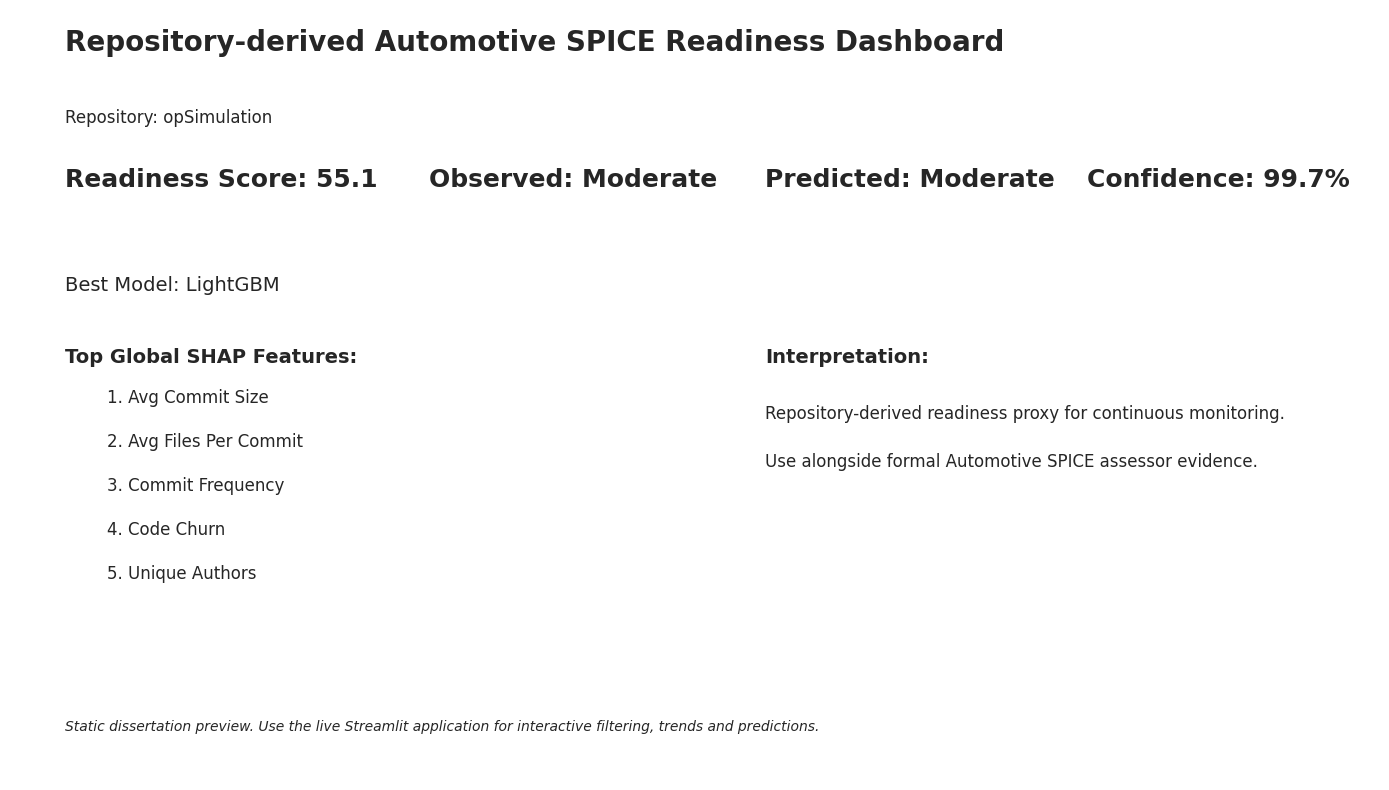

Dashboard preview saved: /content/dashboard/dashboard_report_preview.png


In [26]:
# ============================================================================
# MODULE 11B — STATIC DASHBOARD PREVIEW FOR THE FINAL REPORT
# ============================================================================

# This produces a report-ready static preview using actual outputs.
# The live Streamlit application generated above remains the interactive artifact.

selected_preview_index = int(
    np.argmax(
        final_classifier.predict_proba(
            X_explain
        ).max(axis=1)
    )
)

preview_row = readiness_df.loc[
    X.index[selected_preview_index]
]

preview_score = float(
    preview_row[SCORE_COLUMN]
)

preview_label = str(
    preview_row[TARGET_COLUMN]
)

preview_prediction_int = int(
    final_best_model.predict(
        X.iloc[[selected_preview_index]]
    )[0]
)

preview_prediction_label = INT_TO_CLASS[
    preview_prediction_int
]

preview_confidence = float(
    final_best_model.predict_proba(
        X.iloc[[selected_preview_index]]
    ).max()
)

fig = plt.figure(figsize=(14, 8))

fig.text(
    0.05,
    0.93,
    "Repository-derived Automotive SPICE Readiness Dashboard",
    fontsize=20,
    weight="bold",
)

fig.text(
    0.05,
    0.84,
    f"Repository: {preview_row['repository_name']}",
    fontsize=12,
)

fig.text(
    0.05,
    0.76,
    f"Readiness Score: {preview_score:.1f}",
    fontsize=18,
    weight="bold",
)

fig.text(
    0.31,
    0.76,
    f"Observed: {preview_label}",
    fontsize=18,
    weight="bold",
)

fig.text(
    0.55,
    0.76,
    f"Predicted: {preview_prediction_label}",
    fontsize=18,
    weight="bold",
)

fig.text(
    0.78,
    0.76,
    f"Confidence: {preview_confidence * 100:.1f}%",
    fontsize=18,
    weight="bold",
)

fig.text(
    0.05,
    0.63,
    f"Best Model: {best_model_name}",
    fontsize=14,
)

fig.text(
    0.05,
    0.54,
    "Top Global SHAP Features:",
    fontsize=14,
    weight="bold",
)

for i, feature in enumerate(
    shap_importance_table.head(5)["Feature"]
):
    fig.text(
        0.08,
        0.49 - i * 0.055,
        f"{i + 1}. {feature.replace('_', ' ').title()}",
        fontsize=12,
    )

fig.text(
    0.55,
    0.54,
    "Interpretation:",
    fontsize=14,
    weight="bold",
)

fig.text(
    0.55,
    0.47,
    "Repository-derived readiness proxy for continuous monitoring.",
    fontsize=12,
)

fig.text(
    0.55,
    0.41,
    "Use alongside formal Automotive SPICE assessor evidence.",
    fontsize=12,
)

fig.text(
    0.05,
    0.08,
    "Static dissertation preview. Use the live Streamlit application for interactive filtering, trends and predictions.",
    fontsize=10,
    style="italic",
)

plt.axis("off")
plt.tight_layout()

dashboard_preview_file = (
    DASHBOARD_PATH
    / "dashboard_report_preview.png"
)

plt.savefig(
    dashboard_preview_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Dashboard preview saved:",
    dashboard_preview_file,
)

In [27]:
import sys
import sklearn
import joblib
import lightgbm
import shap
import numpy
import pandas

print("Python        :", sys.version)
print("scikit-learn :", sklearn.__version__)
print("joblib       :", joblib.__version__)
print("lightgbm     :", lightgbm.__version__)
print("shap         :", shap.__version__)
print("numpy        :", numpy.__version__)
print("pandas       :", pandas.__version__)

Python        : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn : 1.6.1
joblib       : 1.5.3
lightgbm     : 4.6.0
shap         : 0.52.0
numpy        : 2.0.2
pandas       : 2.2.2


In [28]:
import sys
import sklearn
import joblib
import lightgbm
import xgboost
import numpy
import pandas
import json

training_environment = {
    "python": sys.version,
    "scikit_learn": sklearn.__version__,
    "joblib": joblib.__version__,
    "lightgbm": lightgbm.__version__,
    "xgboost": xgboost.__version__,
    "numpy": numpy.__version__,
    "pandas": pandas.__version__,
}

print(json.dumps(training_environment, indent=2))

with open(
    "/content/models/training_environment.json",
    "w"
) as f:
    json.dump(training_environment, f, indent=2)

{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "scikit_learn": "1.6.1",
  "joblib": "1.5.3",
  "lightgbm": "4.6.0",
  "xgboost": "3.3.0",
  "numpy": "2.0.2",
  "pandas": "2.2.2"
}


# Final Output Checklist

After a successful run, use these outputs in the final report:

### Section 6.4 — Machine Learning Results
- `tables/model_evaluation/model_comparison.csv`
- `tables/model_evaluation/nested_cv_fold_results.csv`

### Section 6.5 — Model Comparison
- `figures/model_evaluation/model_comparison.png`
- `figures/model_evaluation/best_model_confusion_matrix.png`
- `figures/model_evaluation/best_model_roc_curves.png`
- `tables/model_evaluation/best_model_classification_report.csv`

### Section 6.6 — Explainable AI Results
- `figures/shap/shap_summary_plot.png`
- `figures/shap/shap_feature_importance_bar.png`
- `figures/shap/shap_dependence_plot.png`
- `figures/shap/shap_waterfall_plot.png`
- `figures/shap/shap_local_contribution.png`
- `figures/shap/shap_force_plot.html`
- `tables/shap/shap_global_feature_importance.csv`
- `tables/shap/shap_feature_interactions.csv` *(tree model only)*

### Appendix E
- `tables/model_evaluation/Appendix_E_Actual_Best_Hyperparameters.csv`

### Appendix F
- All SHAP figures and tables above

### Section 6.7 — Dashboard Demonstration
- `dashboard/streamlit_app.py`
- `dashboard/dashboard_report_preview.png`
- Capture screenshots from the running Streamlit application.

### Auto-drafted Results Text
- `report_outputs/Sections_6_4_to_6_7_AutoDraft.txt`